# Multi-Frame vs Bradley-Terry: A Rigorous Comparison

This notebook compares two learning approaches under the **multi-frame data generating process**:

## A) Multi-Frame Learner ("True Model")
- **DGP**: Uses `predict_response_noisy` with τ=τ'=0.25, generating 4 outcome types
- **Policy**: BALD over full 4 outcomes {left, right, indifferent, incomparable}
- **Inference**: Bayesian posterior via hit-and-run MCMC with multi-frame likelihood

## B) Bradley-Terry Baseline ("Strong BT")
- **Inference**: BT logistic model on feature differences, simplex-constrained MAP
  - Uses ONLY decisive outcomes (left/right) in likelihood
  - Ignores indifferent/incomparable in the likelihood (but remembers them for policy)
- **Policy**: BT-consistent uncertainty scoring (Fisher information style)
  - Avoids queries similar to previously rejected ones via rejection memory
  - Does NOT use multi-frame model for query selection

This is a **fair comparison**: BT gets its own optimized query selection without leakage from the multi-frame model.

In [149]:
# ============================================================================
# CELL 1: Imports, Constants, and Helper Utilities
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Set, Optional, Callable, Dict
from scipy.optimize import minimize
from scipy.special import expit as sigmoid
from scipy.stats import logistic as logistic_dist
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Constants
# ============================================================================
FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
DIM = len(FEATURE_NAMES)

# Default model parameters
TAU = 0.25           # Indifference threshold
TAU_PRIME = 0.25     # Incomparability threshold  
LAMBDA_X = 1.0       # Feature scaling

# ============================================================================
# Data Structures (from codebase)
# ============================================================================
@dataclass
class Patient:
    """Represents a patient with feature values."""
    elderlyDep: int
    lifeYearsGained: float
    obesity: int
    weeklyWorkhours: int
    yearsWaiting: int

    def to_array(self) -> np.ndarray:
        return np.array([
            self.elderlyDep, self.lifeYearsGained, self.obesity,
            self.weeklyWorkhours, self.yearsWaiting
        ], dtype=float)

@dataclass
class PairwiseQuery:
    """Represents a pairwise comparison query."""
    patient_left: Patient
    patient_right: Patient
    context: Optional[str] = None

# ============================================================================
# Helper Functions
# ============================================================================
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Compute cosine similarity between two vectors."""
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a < 1e-10 or norm_b < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))

def entropy(probs: np.ndarray) -> float:
    """Compute entropy H[p] = -sum(p * log(p))."""
    probs = np.clip(probs, 1e-15, 1.0)
    return -np.sum(probs * np.log(probs))

def phi(query: PairwiseQuery) -> np.ndarray:
    """Feature difference vector: x_left - x_right."""
    return query.patient_left.to_array() - query.patient_right.to_array()

def generate_random_patient_normalized() -> Patient:
    """Generate a random patient with features in [0, 1]."""
    return Patient(
        elderlyDep=np.random.uniform(0, 1),
        lifeYearsGained=np.random.uniform(0, 1),
        obesity=np.random.uniform(0, 1),
        weeklyWorkhours=np.random.uniform(0, 1),
        yearsWaiting=np.random.uniform(0, 1),
    )

def generate_candidate_queries(n_candidates: int = 100) -> List[PairwiseQuery]:
    """Generate candidate queries with normalized features."""
    candidates = []
    for _ in range(n_candidates):
        left = generate_random_patient_normalized()
        right = generate_random_patient_normalized()
        candidates.append(PairwiseQuery(left, right))
    return candidates

print(f"Initialized with {DIM} features: {FEATURE_NAMES}")
print(f"Default thresholds: τ={TAU}, τ'={TAU_PRIME}")

Initialized with 5 features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
Default thresholds: τ=0.25, τ'=0.25


In [150]:
# ============================================================================
# CELL 2: Multi-Frame Model (DGP + Likelihood + Inference)
# ============================================================================
# These functions define the "true" multi-frame model used as the DGP
# and for Bayesian inference.
# ============================================================================

def compute_frame_gaps(
    query: PairwiseQuery,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    tau: float = TAU
) -> Tuple[np.ndarray, Set[int]]:
    """
    Compute frame-level gaps and identify active frames.
    Returns: (gaps array, set of active frame indices)
    """
    feature_diff = phi(query)
    if V is not None:
        gaps = lambda_x * (V @ feature_diff)
    else:
        gaps = lambda_x * feature_diff
    active_frames = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active_frames


def compute_aggregate_scores(
    gaps: np.ndarray,
    weights: np.ndarray,
    active_frames: Set[int]
) -> Tuple[float, float]:
    """
    Compute aggregate preference score Δ(ω) and intensity r(ω).
    """
    delta_omega = float(np.dot(gaps, weights))
    r_omega = float(sum(weights[j] * abs(gaps[j]) for j in active_frames))
    return delta_omega, r_omega


def create_noise_fn(
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0
) -> Callable:
    """
    Create noise function for latent margins.
    - Δ gets additive noise
    - r gets multiplicative noise (r̃ = r * exp(ε_r)) to stay positive
    """
    def noise_fn(delta: float, r: float) -> Tuple[float, float]:
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(0, scale_delta)
            eps_r = np.random.logistic(0, scale_r) if scale_r > 0 else 0
        else:
            eps_delta = np.random.normal(0, scale_delta)
            eps_r = np.random.normal(0, scale_r) if scale_r > 0 else 0
        delta_tilde = delta + eps_delta
        r_tilde = r * np.exp(eps_r) if scale_r > 0 else r
        return delta_tilde, r_tilde
    return noise_fn


def predict_response_noisy(
    query: PairwiseQuery,
    weights: np.ndarray,
    noise_fn: Callable,
    tau: float = TAU,
    lambda_x: float = LAMBDA_X,
    tau_prime: float = TAU_PRIME,
    V: np.ndarray = None,
) -> str:
    """
    Generate response from multi-frame model with noise.
    Returns: 'left', 'right', 'indifferent', or 'incomparable'
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, weights, active_frames)
    delta_tilde, r_tilde = noise_fn(delta, r)
    
    if r_tilde < tau:
        return 'indifferent'
    if abs(delta_tilde) < tau_prime * r_tilde:
        return 'incomparable'
    return 'left' if delta_tilde >= tau_prime * r_tilde else 'right'


def compute_response_probs_mc(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 200,
) -> np.ndarray:
    """
    Compute P(y | q, ω) for all 4 response types using Monte Carlo.
    Returns: [p_left, p_right, p_indifferent, p_incomparable]
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)
    
    counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
    
    for _ in range(n_mc_samples):
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(0, scale_delta)
            eps_r = np.random.logistic(0, scale_r) if scale_r > 0 else 0
        else:
            eps_delta = np.random.normal(0, scale_delta)
            eps_r = np.random.normal(0, scale_r) if scale_r > 0 else 0
        
        delta_tilde = delta + eps_delta
        r_tilde = r * np.exp(eps_r) if scale_r > 0 else r
        
        if r_tilde < tau:
            counts['indifferent'] += 1
        elif abs(delta_tilde) < tau_prime * r_tilde:
            counts['incomparable'] += 1
        elif delta_tilde >= tau_prime * r_tilde:
            counts['left'] += 1
        else:
            counts['right'] += 1
    
    probs = np.array([counts['left'], counts['right'], 
                      counts['indifferent'], counts['incomparable']]) / n_mc_samples
    return probs


def compute_transcript_log_likelihood(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 100,
) -> float:
    """Compute total log-likelihood of transcript under multi-frame model."""
    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    ll = 0.0
    for query, response in transcript:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        prob = probs[response_idx[response]]
        ll += np.log(max(prob, 1e-10))
    return ll


print("Multi-frame model functions defined:")
print("  - predict_response_noisy: DGP for generating responses")
print("  - compute_response_probs_mc: P(y|q,ω) via Monte Carlo")
print("  - compute_transcript_log_likelihood: for MCMC")

Multi-frame model functions defined:
  - predict_response_noisy: DGP for generating responses
  - compute_response_probs_mc: P(y|q,ω) via Monte Carlo
  - compute_transcript_log_likelihood: for MCMC


In [151]:
# ============================================================================
# CELL 3: Multi-Frame MCMC Sampler
# ============================================================================

def hit_and_run_simplex_step(x: np.ndarray) -> np.ndarray:
    """
    One hit-and-run step on the simplex {w : sum(w)=1, w>=0}.
    """
    dim = len(x)
    d = np.random.randn(dim)
    d = d - d.mean()  # Project onto sum=0
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        return x.copy()
    d = d / norm
    
    t_min, t_max = -np.inf, np.inf
    for j in range(dim):
        if d[j] > 1e-12:
            t_min = max(t_min, -x[j] / d[j])
        elif d[j] < -1e-12:
            t_max = min(t_max, -x[j] / d[j])
    
    if t_min >= t_max - 1e-12:
        return x.copy()
    
    t = np.random.uniform(t_min, t_max)
    new_x = x + t * d
    new_x = np.maximum(new_x, 0.0)
    new_x = new_x / new_x.sum()
    return new_x


def sample_posterior_hit_and_run(
    transcript: List[Tuple[PairwiseQuery, str]],
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_samples: int = 500,
    burn_in: int = 200,
    n_mc_samples: int = 50,
    V: np.ndarray = None,
) -> Tuple[np.ndarray, float]:
    """
    Sample from posterior P(ω | transcript) using hit-and-run + MH.
    Returns: (samples array, acceptance rate)
    """
    dim = DIM
    omega = np.ones(dim) / dim
    
    ll_current = compute_transcript_log_likelihood(
        transcript, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples
    )
    
    samples = []
    n_accepted = 0
    
    for step in range(burn_in + n_samples):
        proposal = hit_and_run_simplex_step(omega)
        ll_proposal = compute_transcript_log_likelihood(
            transcript, proposal, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        
        if np.log(np.random.rand()) < ll_proposal - ll_current:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_accepted += 1
        
        if step >= burn_in:
            samples.append(omega.copy())
    
    return np.array(samples), n_accepted / max(1, n_samples)


print("MCMC sampler defined: sample_posterior_hit_and_run")

MCMC sampler defined: sample_posterior_hit_and_run


In [152]:
# ============================================================================
# CELL 4: Bradley-Terry MAP Fit Under Simplex Constraints
# ============================================================================
#
# BT model: P(left | ω, q) = sigmoid(ωᵀ φ(q))
# where φ(q) = x_left - x_right and ω ∈ simplex.
#
# We fit ω by minimizing:
#   -log_likelihood + (λ/2)||ω||²
# subject to: sum(ω) = 1, ω >= 0
#
# IMPORTANT: BT only uses decisive outcomes (left/right).
# Indifferent/incomparable responses are IGNORED in the likelihood.
# ============================================================================

def fit_bt_simplex(
    transcript: List[Tuple[PairwiseQuery, str]],
    dim: int = DIM,
    l2_reg: float = 1e-2,
    n_restarts: int = 5,
) -> np.ndarray:
    """
    Fit Bradley-Terry model with simplex constraints using SLSQP.
    
    Args:
        transcript: List of (query, response) tuples
        dim: Dimension of weight vector
        l2_reg: L2 regularization strength (λ)
        n_restarts: Number of random restarts
    
    Returns:
        omega_hat: MAP estimate on simplex
    
    Notes:
        - Uses ONLY 'left'/'right' responses (BT is binary)
        - 'indifferent'/'incomparable' responses are IGNORED
        - Numerically stable log-loss implementation
    """
    # Extract decisive outcomes only
    X, y = [], []
    for query, response in transcript:
        if response in ('left', 'right'):
            X.append(phi(query))
            y.append(1.0 if response == 'left' else 0.0)
    
    if len(X) == 0:
        return np.ones(dim) / dim  # Uniform if no decisive data
    
    X = np.array(X)
    y = np.array(y)
    
    def neg_log_posterior(omega):
        """Negative log posterior = neg log likelihood + L2 reg."""
        logits = X @ omega
        # Numerically stable log-loss
        # log(sigmoid(z)) = z - log(1 + exp(z)) for z > 0
        # log(1 - sigmoid(z)) = -log(1 + exp(z)) for z > 0
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        
        nll = -np.sum(y * log_p + (1 - y) * log_1_minus_p)
        reg = 0.5 * l2_reg * np.sum(omega ** 2)
        return nll + reg
    
    # Constraints: sum(ω) = 1
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    # Bounds: ω >= 0
    bounds = [(0, None) for _ in range(dim)]
    
    best_result = None
    for _ in range(n_restarts):
        # Random initialization on simplex
        omega0 = np.random.dirichlet(np.ones(dim))
        
        result = minimize(
            neg_log_posterior,
            omega0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        
        if best_result is None or result.fun < best_result.fun:
            best_result = result
    
    # Ensure on simplex
    omega_hat = np.maximum(best_result.x, 0)
    omega_hat = omega_hat / omega_hat.sum()
    return omega_hat


print("BT fitting function defined: fit_bt_simplex")
print("  - Uses ONLY decisive outcomes (left/right)")
print("  - Simplex constraints via SLSQP")
print("  - L2 regularization for MAP")

BT fitting function defined: fit_bt_simplex
  - Uses ONLY decisive outcomes (left/right)
  - Simplex constraints via SLSQP
  - L2 regularization for MAP


In [153]:
# ============================================================================
# CELL 5: BT Policy with Rejection Memory and Query Scoring
# ============================================================================
#
# BT Query Selection Strategy:
# 1. Uncertainty score: p*(1-p) * ||φ||² where p = sigmoid(ω̂ᵀφ)
#    This is Fisher information style - queries with p≈0.5 are most informative
# 2. Rejection penalty: Avoid queries similar to previously rejected ones
#    penalty = 1 - avoid_strength * max_cosine_sim(φ_normalized, rejected_signatures)
#
# IMPORTANT: BT scoring does NOT use τ, τ', or compute_response_probs.
# It only knows about its own logistic model.
# ============================================================================

class BTRejectionMemory:
    """
    Memory of rejected queries (indifferent/incomparable) for BT policy.
    Stores normalized φ vectors as signatures.
    """
    def __init__(self, avoid_strength: float = 0.5):
        self.signatures: List[np.ndarray] = []  # Normalized φ vectors
        self.avoid_strength = avoid_strength
    
    def add_rejection(self, query: PairwiseQuery):
        """Add a rejected query to memory."""
        phi_vec = phi(query)
        norm = np.linalg.norm(phi_vec)
        if norm > 1e-10:
            self.signatures.append(phi_vec / norm)
    
    def compute_penalty(self, query: PairwiseQuery) -> float:
        """
        Compute rejection avoidance penalty for a query.
        Returns value in [1 - avoid_strength, 1].
        """
        if len(self.signatures) == 0:
            return 1.0
        
        phi_vec = phi(query)
        norm = np.linalg.norm(phi_vec)
        if norm < 1e-10:
            return 1.0 - self.avoid_strength  # Very similar to some rejection
        
        sig = phi_vec / norm
        max_sim = max(abs(np.dot(sig, s)) for s in self.signatures)
        return 1.0 - self.avoid_strength * max(0, max_sim)


def bt_query_score(
    query: PairwiseQuery,
    omega_hat: np.ndarray,
    rejection_memory: BTRejectionMemory,
) -> float:
    """
    BT-consistent query score (Fisher information style).
    
    score = p*(1-p) * ||φ||² * rejection_penalty
    
    where:
    - p = sigmoid(ω̂ᵀφ) is BT's predicted P(left)
    - ||φ||² scales by feature difference magnitude
    - rejection_penalty avoids queries similar to past rejections
    
    This is pure BT scoring - no multi-frame model knowledge.
    """
    phi_vec = phi(query)
    logit = np.dot(omega_hat, phi_vec)
    p = sigmoid(logit)
    
    # Fisher information for logistic: p*(1-p)
    # Scale by ||φ||² (larger differences = more informative)
    uncertainty = p * (1 - p) * np.dot(phi_vec, phi_vec)
    
    # Rejection avoidance penalty
    penalty = rejection_memory.compute_penalty(query)
    
    return uncertainty * penalty


def bt_select_query(
    candidates: List[PairwiseQuery],
    omega_hat: np.ndarray,
    rejection_memory: BTRejectionMemory,
) -> PairwiseQuery:
    """Select best query according to BT scoring."""
    best_query = None
    best_score = -np.inf
    
    for query in candidates:
        score = bt_query_score(query, omega_hat, rejection_memory)
        if score > best_score:
            best_score = score
            best_query = query
    
    return best_query if best_query is not None else candidates[0]


print("BT policy functions defined:")
print("  - BTRejectionMemory: tracks rejected queries")
print("  - bt_query_score: Fisher info + rejection penalty")
print("  - bt_select_query: selects best BT query")

BT policy functions defined:
  - BTRejectionMemory: tracks rejected queries
  - bt_query_score: Fisher info + rejection penalty
  - bt_select_query: selects best BT query


In [154]:
# ============================================================================
# CELL 6: Multi-Frame BALD Query Selection
# ============================================================================
#
# BALD = H[E_ω p(y|q,ω)] - E_ω[H[p(y|q,ω)]]
#
# Uses the full 4-outcome distribution from compute_response_probs_mc.
# This is the multi-frame model's query selection strategy.
# ============================================================================

def multiframe_bald_score(
    query: PairwiseQuery,
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 50,
    max_samples: int = 50,
) -> float:
    """
    Compute BALD score for a query using full 4-outcome model.
    
    BALD = H[E_ω p(y|q,ω)] - E_ω[H[p(y|q,ω)]]
    """
    n_samples = min(len(posterior_samples), max_samples)
    if n_samples == 0:
        return 0.0
    
    all_probs = []
    for omega in posterior_samples[:n_samples]:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        probs = np.clip(probs, 1e-10, 1.0)
        probs = probs / probs.sum()
        all_probs.append(probs)
    
    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    
    return H_avg - avg_H


def multiframe_select_query(
    candidates: List[PairwiseQuery],
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
) -> PairwiseQuery:
    """Select best query according to multi-frame BALD."""
    best_query = None
    best_score = -np.inf
    
    for query in candidates:
        score = multiframe_bald_score(
            query, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V
        )
        if score > best_score:
            best_score = score
            best_query = query
    
    return best_query if best_query is not None else candidates[0]


print("Multi-frame BALD functions defined:")
print("  - multiframe_bald_score: BALD over 4 outcomes")
print("  - multiframe_select_query: selects best BALD query")

Multi-frame BALD functions defined:
  - multiframe_bald_score: BALD over 4 outcomes
  - multiframe_select_query: selects best BALD query


In [155]:
# ============================================================================
# CELL 7: Trial Runners for Both Methods
# ============================================================================

def run_bt_trial(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    avoid_strength: float = 0.5,
    l2_reg: float = 1e-2,
    seed: int = None,
) -> Dict:
    """
    Run one BT active learning trial.
    
    This is the STRONG BT baseline:
    - Query selection: BT-consistent Fisher info + rejection avoidance
    - Inference: BT MAP on simplex using only decisive outcomes
    - Policy memory: Remembers rejected queries to avoid similar ones
    
    Returns dict with:
        - cos_sims: list of cosine similarities per attempt
        - n_decisive: list of cumulative decisive count per attempt
        - responses: Counter of all responses
    """
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    transcript = []
    rejection_memory = BTRejectionMemory(avoid_strength=avoid_strength)
    omega_hat = np.ones(dim) / dim  # Start uniform
    
    cos_sims = []
    n_decisive_list = []
    responses = Counter()
    
    for t in range(n_attempts):
        # Generate candidates
        candidates = generate_candidate_queries(n_candidates)
        
        # Select query using BT scoring (no multi-frame knowledge!)
        query = bt_select_query(candidates, omega_hat, rejection_memory)
        
        # Get oracle response (from multi-frame DGP)
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((query, response))
        responses[response] += 1
        
        # Update rejection memory if non-decisive
        if response in ('indifferent', 'incomparable'):
            rejection_memory.add_rejection(query)
        
        # Re-fit BT using only decisive outcomes
        omega_hat = fit_bt_simplex(transcript, dim, l2_reg=l2_reg)
        
        # Track metrics
        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        n_decisive = responses['left'] + responses['right']
        n_decisive_list.append(n_decisive)
    
    return {
        'cos_sims': cos_sims,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'final_estimate': omega_hat,
    }


def run_multiframe_trial(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    seed: int = None,
) -> Dict:
    """
    Run one multi-frame active learning trial.
    
    This is the "true model":
    - Query selection: BALD over full 4 outcomes
    - Inference: Bayesian posterior via MCMC with multi-frame likelihood
    
    Returns dict with:
        - cos_sims: list of cosine similarities per attempt
        - n_decisive: list of cumulative decisive count per attempt
        - responses: Counter of all responses
    """
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    transcript = []
    
    cos_sims = []
    n_decisive_list = []
    responses = Counter()
    
    # Initial uniform prior samples
    posterior_samples = np.random.dirichlet(np.ones(dim), size=n_posterior_samples)
    
    for t in range(n_attempts):
        # Generate candidates
        candidates = generate_candidate_queries(n_candidates)
        
        # Select query using multi-frame BALD
        query = multiframe_select_query(
            candidates, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x
        )
        
        # Get oracle response (from multi-frame DGP)
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((query, response))
        responses[response] += 1
        
        # Update posterior
        posterior_samples, _ = sample_posterior_hit_and_run(
            transcript, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples,
            burn_in=100,
            n_mc_samples=30,
        )
        
        # Posterior mean as point estimate
        omega_hat = posterior_samples.mean(axis=0)
        
        # Track metrics
        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        n_decisive = responses['left'] + responses['right']
        n_decisive_list.append(n_decisive)
    
    return {
        'cos_sims': cos_sims,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'final_estimate': posterior_samples.mean(axis=0),
    }


print("Trial runners defined:")
print("  - run_bt_trial: Strong BT baseline with rejection memory")
print("  - run_multiframe_trial: Full Bayesian with 4-way BALD")

Trial runners defined:
  - run_bt_trial: Strong BT baseline with rejection memory
  - run_multiframe_trial: Full Bayesian with 4-way BALD


In [156]:
# # ============================================================================
# # CELL 8: Run Experiment
# # ============================================================================

# # Experiment parameters
# N_TRIALS = 15          # Number of random trials
# N_ATTEMPTS = 50        # Attempts per trial
# N_CANDIDATES = 50     # Candidate queries per round

# # Model parameters
# TAU_EXP = 0.25
# TAU_PRIME_EXP = 0.25
# SCALE_DELTA = 0.3
# SCALE_R = 0.0
# NOISE_TYPE = 'logistic'

# # Fixed oracle (for reproducibility)
# np.random.seed(42)
# ORACLE_WEIGHTS = np.random.dirichlet(np.ones(DIM))
# print(f"Oracle weights: {ORACLE_WEIGHTS.round(3)}")
# print(f"Settings: τ={TAU_EXP}, τ'={TAU_PRIME_EXP}, scale_δ={SCALE_DELTA}")
# print(f"Running {N_TRIALS} trials × {N_ATTEMPTS} attempts each...")
# print()

# # Storage
# bt_results = []
# mf_results = []

# for trial in range(N_TRIALS):
#     seed = 1000 + trial
    
#     # Create noise function
#     noise_fn = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
    
#     # Run BT trial
#     np.random.seed(seed)
#     noise_fn_bt = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
#     bt_result = run_bt_trial(
#         ORACLE_WEIGHTS, noise_fn_bt, TAU_EXP, TAU_PRIME_EXP, LAMBDA_X,
#         N_ATTEMPTS, N_CANDIDATES, avoid_strength=0.5, seed=seed
#     )
#     bt_results.append(bt_result)
    
#     # Run multi-frame trial (same seed for fair comparison)
#     np.random.seed(seed)
#     noise_fn_mf = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
#     mf_result = run_multiframe_trial(
#         ORACLE_WEIGHTS, noise_fn_mf, NOISE_TYPE, SCALE_DELTA, SCALE_R,
#         TAU_EXP, TAU_PRIME_EXP, LAMBDA_X, N_ATTEMPTS, N_CANDIDATES, seed=seed
#     )
#     mf_results.append(mf_result)
    
#     # Progress
#     bt_final = bt_result['cos_sims'][-1]
#     mf_final = mf_result['cos_sims'][-1]
#     bt_dec = bt_result['n_decisive'][-1]
#     print(f"Trial {trial+1:2d}: BT cos={bt_final:.3f} ({bt_dec} decisive), "
#           f"MF cos={mf_final:.3f}")

# print("\nExperiment complete!")

In [157]:
# # ============================================================================
# # CELL 9: Aggregate Results
# # ============================================================================

# # Convert to arrays for easy aggregation
# bt_cos_sims = np.array([r['cos_sims'] for r in bt_results])  # (N_TRIALS, N_ATTEMPTS)
# mf_cos_sims = np.array([r['cos_sims'] for r in mf_results])

# bt_n_decisive = np.array([r['n_decisive'] for r in bt_results])
# mf_n_decisive = np.array([r['n_decisive'] for r in mf_results])

# # Compute means and standard errors
# bt_mean = bt_cos_sims.mean(axis=0)
# bt_stderr = bt_cos_sims.std(axis=0) / np.sqrt(N_TRIALS)

# mf_mean = mf_cos_sims.mean(axis=0)
# mf_stderr = mf_cos_sims.std(axis=0) / np.sqrt(N_TRIALS)

# bt_dec_mean = bt_n_decisive.mean(axis=0)
# bt_dec_stderr = bt_n_decisive.std(axis=0) / np.sqrt(N_TRIALS)

# mf_dec_mean = mf_n_decisive.mean(axis=0)
# mf_dec_stderr = mf_n_decisive.std(axis=0) / np.sqrt(N_TRIALS)

# # Aggregate response counts
# bt_total_responses = Counter()
# mf_total_responses = Counter()
# for r in bt_results:
#     bt_total_responses += r['responses']
# for r in mf_results:
#     mf_total_responses += r['responses']

# print("Aggregation complete.")
# print(f"\nBT total responses across all trials: {dict(bt_total_responses)}")
# print(f"MF total responses across all trials: {dict(mf_total_responses)}")

In [158]:
# # ============================================================================
# # CELL 10: Plots
# # ============================================================================

# # Try to use style.py if available
# try:
#     import sys
#     sys.path.insert(0, '/Users/michellesi/Desktop/harvard/topmodel/learning-algo')
#     from style import paper_style, SINGLE_COLUMN, COLOR_A, COLOR_B
#     USE_STYLE = True
# except:
#     USE_STYLE = False
#     COLOR_A = '#4477AA'  # Blue
#     COLOR_B = '#EE6677'  # Red

# attempts = np.arange(1, N_ATTEMPTS + 1)

# fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# # Left plot: Cosine similarity convergence
# ax1 = axes[0]
# ax1.plot(attempts, mf_mean, '-', color=COLOR_A, label='Multi-Frame (BALD)', linewidth=2)
# ax1.fill_between(attempts, mf_mean - mf_stderr, mf_mean + mf_stderr, 
#                   color=COLOR_A, alpha=0.2)
# ax1.plot(attempts, bt_mean, '-', color=COLOR_B, label='BT (Strong Baseline)', linewidth=2)
# ax1.fill_between(attempts, bt_mean - bt_stderr, bt_mean + bt_stderr,
#                   color=COLOR_B, alpha=0.2)
# ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
# ax1.set_xlabel('Number of Queries')
# ax1.set_ylabel('Cosine Similarity to Oracle')
# ax1.set_title(f'Convergence (τ=τ\'={TAU_EXP}, {N_TRIALS} trials)')
# ax1.legend(loc='lower right')
# ax1.set_ylim([0, 1.05])
# ax1.set_xlim([1, N_ATTEMPTS])

# # Right plot: Decisive queries obtained
# ax2 = axes[1]
# ax2.plot(attempts, mf_dec_mean, '-', color=COLOR_A, label='Multi-Frame', linewidth=2)
# ax2.fill_between(attempts, mf_dec_mean - mf_dec_stderr, mf_dec_mean + mf_dec_stderr,
#                   color=COLOR_A, alpha=0.2)
# ax2.plot(attempts, bt_dec_mean, '-', color=COLOR_B, label='BT', linewidth=2)
# ax2.fill_between(attempts, bt_dec_mean - bt_dec_stderr, bt_dec_mean + bt_dec_stderr,
#                   color=COLOR_B, alpha=0.2)
# ax2.plot([0, N_ATTEMPTS], [0, N_ATTEMPTS], 'k--', alpha=0.3, linewidth=0.8)
# ax2.set_xlabel('Number of Queries')
# ax2.set_ylabel('Decisive Responses (L/R)')
# ax2.set_title('Query Efficiency')
# ax2.legend(loc='lower right')
# ax2.set_xlim([1, N_ATTEMPTS])

# plt.tight_layout()
# plt.savefig('bt_vs_multiframe_comparison.pdf', bbox_inches='tight', dpi=150)
# plt.show()

# print("\nFigure saved to bt_vs_multiframe_comparison.pdf")

In [159]:
# # ============================================================================
# # CELL 11: Summary Table
# # ============================================================================

# print("=" * 70)
# print("EXPERIMENT SUMMARY")
# print("=" * 70)
# print(f"\nSettings:")
# print(f"  Oracle weights: {ORACLE_WEIGHTS.round(3)}")
# print(f"  τ = τ' = {TAU_EXP}")
# print(f"  Noise: {NOISE_TYPE}, scale_δ = {SCALE_DELTA}, scale_r = {SCALE_R}")
# print(f"  Trials: {N_TRIALS}, Attempts per trial: {N_ATTEMPTS}")

# print(f"\n{'Metric':<30} {'Multi-Frame':>15} {'BT (Strong)':>15}")
# print("-" * 60)

# # Final cosine similarity
# print(f"{'Final cos_sim (mean ± SE)':<30} {mf_mean[-1]:.3f} ± {mf_stderr[-1]:.3f}     {bt_mean[-1]:.3f} ± {bt_stderr[-1]:.3f}")

# # Cosine at midpoint
# mid = N_ATTEMPTS // 2 - 1
# print(f"{'Cos_sim at t={N_ATTEMPTS//2} (mean ± SE)':<30} {mf_mean[mid]:.3f} ± {mf_stderr[mid]:.3f}     {bt_mean[mid]:.3f} ± {bt_stderr[mid]:.3f}")

# # Decisive rate
# bt_dec_rate = bt_dec_mean[-1] / N_ATTEMPTS
# mf_dec_rate = mf_dec_mean[-1] / N_ATTEMPTS
# print(f"{'Decisive rate (final)':<30} {mf_dec_rate:.1%}            {bt_dec_rate:.1%}")

# # Response breakdown
# print(f"\nResponse breakdown (total across all trials):")
# print(f"  Multi-Frame: {dict(mf_total_responses)}")
# print(f"  BT:          {dict(bt_total_responses)}")

# # Statistical test
# from scipy.stats import ttest_ind
# final_mf = [r['cos_sims'][-1] for r in mf_results]
# final_bt = [r['cos_sims'][-1] for r in bt_results]
# t_stat, p_value = ttest_ind(final_mf, final_bt)
# print(f"\nTwo-sample t-test (final cos_sim): t={t_stat:.2f}, p={p_value:.4f}")
# if p_value < 0.05:
#     winner = "Multi-Frame" if np.mean(final_mf) > np.mean(final_bt) else "BT"
#     print(f"  → {winner} significantly better at α=0.05")
# else:
#     print(f"  → No significant difference at α=0.05")

# print("\n" + "=" * 70)

# Protocol 2: Fixed Decisive Budget

**Question**: If we give both methods the same amount of *usable* information, how do they compare?

- **BT**: Run until it collects K=50 decisive labels (left/right). Track total attempts needed.
- **Multi-Frame**: Run for exactly K=50 queries. It uses ALL responses for inference.

This compares:
1. Cosine similarity vs. decisive labels (what BT actually uses)
2. How many extra attempts BT needs to get K decisive labels
3. Multi-frame's performance with the same query budget as BT's decisive count

In [160]:
# # ============================================================================
# # CELL 12: Protocol 2 - Trial Runners for Fixed Decisive Budget
# # ============================================================================

# def run_bt_until_k_decisive(
#     oracle_weights: np.ndarray,
#     noise_fn: Callable,
#     tau: float,
#     tau_prime: float,
#     lambda_x: float,
#     k_decisive: int,
#     n_candidates: int = 100,
#     avoid_strength: float = 0.5,
#     l2_reg: float = 1e-2,
#     max_attempts: int = 500,  # Safety limit
#     seed: int = None,
# ) -> Dict:
#     """
#     Run BT until it collects exactly k_decisive left/right responses.
    
#     Returns dict with:
#         - cos_sims_by_decisive: cosine sim after each decisive label (length = k_decisive)
#         - total_attempts: how many queries were needed
#         - responses: Counter of all responses
#     """
#     if seed is not None:
#         np.random.seed(seed)
    
#     dim = len(oracle_weights)
#     transcript = []
#     rejection_memory = BTRejectionMemory(avoid_strength=avoid_strength)
#     omega_hat = np.ones(dim) / dim
    
#     cos_sims_by_decisive = []  # Track cos_sim after each decisive response
#     responses = Counter()
#     n_decisive = 0
#     attempt = 0
    
#     while n_decisive < k_decisive and attempt < max_attempts:
#         candidates = generate_candidate_queries(n_candidates)
#         query = bt_select_query(candidates, omega_hat, rejection_memory)
        
#         response = predict_response_noisy(
#             query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
#         )
#         transcript.append((query, response))
#         responses[response] += 1
#         attempt += 1
        
#         if response in ('indifferent', 'incomparable'):
#             rejection_memory.add_rejection(query)
#         else:
#             # Decisive response - update estimate and record
#             n_decisive += 1
#             omega_hat = fit_bt_simplex(transcript, dim, l2_reg=l2_reg)
#             cos_sims_by_decisive.append(cosine_similarity(omega_hat, oracle_weights))
    
#     return {
#         'cos_sims_by_decisive': cos_sims_by_decisive,
#         'total_attempts': attempt,
#         'n_decisive': n_decisive,
#         'responses': responses,
#         'final_estimate': omega_hat,
#     }


# def run_multiframe_k_queries(
#     oracle_weights: np.ndarray,
#     noise_fn: Callable,
#     noise_type: str,
#     scale_delta: float,
#     scale_r: float,
#     tau: float,
#     tau_prime: float,
#     lambda_x: float,
#     k_queries: int,
#     n_candidates: int = 100,
#     n_posterior_samples: int = 300,
#     seed: int = None,
# ) -> Dict:
#     """
#     Run multi-frame for exactly k_queries.
#     Track cosine sim after each query (to compare with BT's per-decisive).
    
#     Returns dict with:
#         - cos_sims: cosine sim after each query (length = k_queries)
#         - n_decisive: how many were decisive
#         - responses: Counter of all responses
#     """
#     if seed is not None:
#         np.random.seed(seed)
    
#     dim = len(oracle_weights)
#     transcript = []
    
#     cos_sims = []
#     responses = Counter()
    
#     posterior_samples = np.random.dirichlet(np.ones(dim), size=n_posterior_samples)
    
#     for t in range(k_queries):
#         candidates = generate_candidate_queries(n_candidates)
#         query = multiframe_select_query(
#             candidates, posterior_samples, noise_type, scale_delta, scale_r,
#             tau, tau_prime, lambda_x
#         )
        
#         response = predict_response_noisy(
#             query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
#         )
#         transcript.append((query, response))
#         responses[response] += 1
        
#         posterior_samples, _ = sample_posterior_hit_and_run(
#             transcript, noise_type, scale_delta, scale_r,
#             tau, tau_prime, lambda_x,
#             n_samples=n_posterior_samples,
#             burn_in=100,
#             n_mc_samples=30,
#         )
        
#         omega_hat = posterior_samples.mean(axis=0)
#         cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
    
#     return {
#         'cos_sims': cos_sims,
#         'n_decisive': responses['left'] + responses['right'],
#         'responses': responses,
#         'final_estimate': posterior_samples.mean(axis=0),
#     }


# print("Protocol 2 trial runners defined:")
# print("  - run_bt_until_k_decisive: run BT until K decisive labels")
# print("  - run_multiframe_k_queries: run multi-frame for K queries")

In [161]:
# # ============================================================================
# # CELL 13: Run Protocol 2 Experiment
# # ============================================================================

# K_DECISIVE = 50  # Target number of decisive labels for BT

# print(f"Protocol 2: BT runs until {K_DECISIVE} decisive labels")
# print(f"            Multi-frame runs for {K_DECISIVE} queries")
# print(f"Running {N_TRIALS} trials...")
# print()

# # Storage
# bt_p2_results = []
# mf_p2_results = []

# for trial in range(N_TRIALS):
#     seed = 2000 + trial  # Different seed range from Protocol 1
    
#     # Run BT until K decisive
#     np.random.seed(seed)
#     noise_fn_bt = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
#     bt_result = run_bt_until_k_decisive(
#         ORACLE_WEIGHTS, noise_fn_bt, TAU_EXP, TAU_PRIME_EXP, LAMBDA_X,
#         K_DECISIVE, N_CANDIDATES, avoid_strength=0.5, seed=seed
#     )
#     bt_p2_results.append(bt_result)
    
#     # Run multi-frame for K queries
#     np.random.seed(seed)
#     noise_fn_mf = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
#     mf_result = run_multiframe_k_queries(
#         ORACLE_WEIGHTS, noise_fn_mf, NOISE_TYPE, SCALE_DELTA, SCALE_R,
#         TAU_EXP, TAU_PRIME_EXP, LAMBDA_X, K_DECISIVE, N_CANDIDATES, seed=seed
#     )
#     mf_p2_results.append(mf_result)
    
#     # Progress
#     bt_attempts = bt_result['total_attempts']
#     bt_final = bt_result['cos_sims_by_decisive'][-1] if bt_result['cos_sims_by_decisive'] else 0
#     mf_final = mf_result['cos_sims'][-1]
#     mf_dec = mf_result['n_decisive']
#     print(f"Trial {trial+1:2d}: BT needed {bt_attempts} attempts (cos={bt_final:.3f}), "
#           f"MF got {mf_dec} decisive in {K_DECISIVE} queries (cos={mf_final:.3f})")

# print("\nProtocol 2 experiment complete!")

In [162]:
# # ============================================================================
# # CELL 14: Protocol 2 - Aggregate and Plot
# # ============================================================================

# # Aggregate BT results (indexed by decisive label count)
# bt_p2_cos_sims = np.array([r['cos_sims_by_decisive'] for r in bt_p2_results])  # (N_TRIALS, K_DECISIVE)
# bt_p2_attempts = np.array([r['total_attempts'] for r in bt_p2_results])

# # Aggregate MF results (indexed by query count)
# mf_p2_cos_sims = np.array([r['cos_sims'] for r in mf_p2_results])  # (N_TRIALS, K_DECISIVE)
# mf_p2_n_decisive = np.array([r['n_decisive'] for r in mf_p2_results])

# # Compute means and stderr
# bt_p2_mean = bt_p2_cos_sims.mean(axis=0)
# bt_p2_stderr = bt_p2_cos_sims.std(axis=0) / np.sqrt(N_TRIALS)

# mf_p2_mean = mf_p2_cos_sims.mean(axis=0)
# mf_p2_stderr = mf_p2_cos_sims.std(axis=0) / np.sqrt(N_TRIALS)

# decisive_labels = np.arange(1, K_DECISIVE + 1)

# # ============================================================================
# # Plot 1: Cosine similarity vs decisive labels / queries
# # ============================================================================
# fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ax1 = axes[0]
# ax1.plot(decisive_labels, bt_p2_mean, '-', color=COLOR_B, 
#          label=f'BT (vs decisive labels)', linewidth=2)
# ax1.fill_between(decisive_labels, bt_p2_mean - bt_p2_stderr, bt_p2_mean + bt_p2_stderr,
#                   color=COLOR_B, alpha=0.2)
# ax1.plot(decisive_labels, mf_p2_mean, '-', color=COLOR_A,
#          label=f'Multi-Frame (vs queries)', linewidth=2)
# ax1.fill_between(decisive_labels, mf_p2_mean - mf_p2_stderr, mf_p2_mean + mf_p2_stderr,
#                   color=COLOR_A, alpha=0.2)
# ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
# ax1.set_xlabel('Decisive Labels (BT) / Queries (MF)')
# ax1.set_ylabel('Cosine Similarity to Oracle')
# ax1.set_title(f'Protocol 2: Fixed Budget Comparison (K={K_DECISIVE})')
# ax1.legend(loc='lower right')
# ax1.set_ylim([0, 1.05])
# ax1.set_xlim([1, K_DECISIVE])

# # Plot 2: Distribution of attempts needed by BT
# ax2 = axes[1]
# ax2.hist(bt_p2_attempts, bins=15, color=COLOR_B, alpha=0.7, edgecolor='black')
# ax2.axvline(x=K_DECISIVE, color=COLOR_A, linestyle='--', linewidth=2, 
#             label=f'MF queries = {K_DECISIVE}')
# ax2.axvline(x=bt_p2_attempts.mean(), color=COLOR_B, linestyle='-', linewidth=2,
#             label=f'BT mean = {bt_p2_attempts.mean():.1f}')
# ax2.set_xlabel('Total Attempts Needed')
# ax2.set_ylabel('Count')
# ax2.set_title(f'BT Attempts to Reach {K_DECISIVE} Decisive Labels')
# ax2.legend()

# plt.tight_layout()
# plt.savefig('protocol2_fixed_budget.pdf', bbox_inches='tight', dpi=150)
# plt.show()

# print("Figure saved to protocol2_fixed_budget.pdf")

In [163]:
# # ============================================================================
# # CELL 15: Protocol 2 - Summary Table
# # ============================================================================

# print("=" * 70)
# print("PROTOCOL 2 SUMMARY: Fixed Decisive Budget")
# print("=" * 70)

# print(f"\nSetup:")
# print(f"  BT: Run until {K_DECISIVE} decisive labels collected")
# print(f"  Multi-Frame: Run for exactly {K_DECISIVE} queries")

# print(f"\n{'Metric':<40} {'Multi-Frame':>12} {'BT':>12}")
# print("-" * 65)

# # Final cosine similarity
# mf_final_mean = mf_p2_cos_sims[:, -1].mean()
# mf_final_se = mf_p2_cos_sims[:, -1].std() / np.sqrt(N_TRIALS)
# bt_final_mean = bt_p2_cos_sims[:, -1].mean()
# bt_final_se = bt_p2_cos_sims[:, -1].std() / np.sqrt(N_TRIALS)
# print(f"{'Final cos_sim (mean ± SE)':<40} {mf_final_mean:.3f}±{mf_final_se:.3f}    {bt_final_mean:.3f}±{bt_final_se:.3f}")

# # Queries/attempts used
# print(f"{'Queries used (mean ± SE)':<40} {K_DECISIVE:.1f}±0.0        {bt_p2_attempts.mean():.1f}±{bt_p2_attempts.std()/np.sqrt(N_TRIALS):.1f}")

# # Overhead ratio
# overhead = bt_p2_attempts.mean() / K_DECISIVE
# print(f"{'Attempt overhead ratio (BT/K)':<40} {'1.00':>12} {overhead:.2f}")

# # Decisive rate for MF
# mf_dec_rate = mf_p2_n_decisive.mean() / K_DECISIVE
# print(f"{'MF decisive rate':<40} {mf_dec_rate:.1%}")

# print(f"\n{'At midpoint (K/2 = '}{K_DECISIVE//2}{'):':<28} {'Multi-Frame':>12} {'BT':>12}")
# print("-" * 65)
# mid = K_DECISIVE // 2 - 1
# mf_mid = mf_p2_cos_sims[:, mid].mean()
# bt_mid = bt_p2_cos_sims[:, mid].mean()
# print(f"{'Cos_sim':<40} {mf_mid:.3f}         {bt_mid:.3f}")

# # Statistical comparison at final point
# print(f"\nStatistical Tests:")
# final_mf = mf_p2_cos_sims[:, -1]
# final_bt = bt_p2_cos_sims[:, -1]

# # Test 1: Final cosine similarity
# t_stat, p_value = ttest_ind(final_mf, final_bt)
# print(f"  Final cos_sim t-test: t={t_stat:.2f}, p={p_value:.4f}")
# if p_value < 0.05:
#     winner = "Multi-Frame" if final_mf.mean() > final_bt.mean() else "BT"
#     print(f"    → {winner} significantly better")

# # Test 2: Is BT overhead significant?
# # Compare BT attempts to K_DECISIVE
# from scipy.stats import ttest_1samp
# t_stat2, p_value2 = ttest_1samp(bt_p2_attempts, K_DECISIVE)
# print(f"  BT attempts vs K={K_DECISIVE}: t={t_stat2:.2f}, p={p_value2:.4f}")
# if p_value2 < 0.05 and bt_p2_attempts.mean() > K_DECISIVE:
#     print(f"    → BT needs significantly more attempts than K")

# print(f"\nInterpretation:")
# print(f"  - BT needed {overhead:.1%} as many attempts to get {K_DECISIVE} usable labels")
# print(f"  - Multi-Frame used ALL {K_DECISIVE} responses for inference")
# if final_mf.mean() > final_bt.mean():
#     gap = final_mf.mean() - final_bt.mean()
#     print(f"  - Multi-Frame achieved {gap:.3f} higher cos_sim with same 'usable' data budget")
# else:
#     gap = final_bt.mean() - final_mf.mean()
#     print(f"  - BT achieved {gap:.3f} higher cos_sim despite query overhead")

# print("\n" + "=" * 70)

# Protocol 3: BT with Forced Choice

**Question**: What if BT forces non-decisive responses into decisive labels?

This is a common real-world approach: when a human says "I can't decide" or "these are incomparable", 
the system forces them to pick one anyway.

**Forced-choice modes**:
- `forced_choice=None`: Original BT baseline (skip non-decisive, use rejection memory)
- `forced_choice="random"`: Convert indifferent/incomparable to random left/right (coin flip)
- `forced_choice="left"`: Convert indifferent/incomparable to always "left"

**Key difference from baseline BT**:
- Baseline BT: Uses only naturally decisive responses for inference
- Forced BT: Uses ALL responses (converting non-decisive to forced decisions)

This tests whether forcing decisions helps or hurts BT's convergence.

In [164]:
# ============================================================================
# CELL 16: Forced Choice Helper and BT Trial Runner
# ============================================================================
# NEW CODE - does not modify existing functions

from typing import Optional

def force_choice(
    raw_response: str,
    mode: Optional[str],
    rng: np.random.Generator,
) -> str:
    """
    Convert a raw oracle response to a forced decisive label if needed.
    
    Args:
        raw_response: Original response from oracle ('left', 'right', 'indifferent', 'incomparable')
        mode: Forced-choice mode:
            - None: Return raw_response unchanged (original behavior)
            - "random": If non-decisive, flip fair coin
            - "left": If non-decisive, always return "left"
        rng: NumPy random generator for reproducibility
    
    Returns:
        'left' or 'right' (either original or forced)
    """
    # Already decisive - return as-is
    if raw_response in ('left', 'right'):
        return raw_response
    
    # Non-decisive response
    if mode is None:
        # No forcing - return original (caller handles skipping)
        return raw_response
    elif mode == "random":
        return "left" if rng.random() < 0.5 else "right"
    elif mode == "left":
        return "left"
    else:
        raise ValueError(f"Unknown forced_choice mode: {mode}")


def fit_bt_simplex_forced(
    transcript: List[Tuple[PairwiseQuery, str]],
    forced_transcript: List[Tuple[PairwiseQuery, str]],
    dim: int = DIM,
    l2_reg: float = 1e-2,
    n_restarts: int = 5,
    use_forced: bool = False,
) -> np.ndarray:
    """
    Fit BT model with simplex constraints.
    
    Args:
        transcript: Original (query, raw_response) pairs
        forced_transcript: (query, forced_response) pairs where non-decisive are converted
        dim: Weight dimension
        l2_reg: L2 regularization strength
        n_restarts: Optimization restarts
        use_forced: If True, use forced_transcript; if False, use only decisive from transcript
    
    Returns:
        omega_hat: MAP estimate on simplex
    """
    # Select which data to use
    if use_forced:
        # Use ALL responses (forced to be decisive)
        data_source = forced_transcript
    else:
        # Use only naturally decisive responses
        data_source = [(q, r) for q, r in transcript if r in ('left', 'right')]
    
    if len(data_source) == 0:
        return np.ones(dim) / dim
    
    X = np.array([phi(q) for q, r in data_source])
    y = np.array([1.0 if r == 'left' else 0.0 for q, r in data_source])
    
    def neg_log_posterior(omega):
        logits = X @ omega
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        nll = -np.sum(y * log_p + (1 - y) * log_1_minus_p)
        reg = 0.5 * l2_reg * np.sum(omega ** 2)
        return nll + reg
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = [(0, None) for _ in range(dim)]
    
    best_result = None
    for _ in range(n_restarts):
        omega0 = np.random.dirichlet(np.ones(dim))
        result = minimize(
            neg_log_posterior, omega0, method='SLSQP',
            bounds=bounds, constraints=constraints,
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result
    
    omega_hat = np.maximum(best_result.x, 0)
    omega_hat = omega_hat / omega_hat.sum()
    return omega_hat


def run_bt_trial_forced(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    forced_choice: Optional[str] = None,  # None, "random", or "left"
    n_candidates: int = 100,
    l2_reg: float = 1e-2,
    seed: int = None,
) -> Dict:
    """
    Run BT trial with optional forced-choice conversion.
    
    This is a NEW function that does NOT modify the existing run_bt_trial.
    
    Args:
        oracle_weights: True oracle weights
        noise_fn: Noise function for DGP
        tau, tau_prime, lambda_x: DGP parameters (BT doesn't use these internally)
        n_attempts: Number of queries to ask
        forced_choice: Forced-choice mode:
            - None: Original baseline (use only decisive, no forcing)
            - "random": Force non-decisive to random left/right
            - "left": Force non-decisive to always "left"
        n_candidates: Candidates per round
        l2_reg: L2 regularization for BT fit
        seed: Random seed
    
    Returns dict with:
        - cos_sims: cosine similarity after each attempt
        - raw_responses: Counter of raw oracle responses
        - forced_responses: Counter of responses after forcing (same as raw if forced_choice=None)
        - n_forced: number of non-decisive responses that were forced
    """
    rng = np.random.default_rng(seed)
    if seed is not None:
        np.random.seed(seed)  # For other numpy calls
    
    dim = len(oracle_weights)
    transcript = []           # (query, raw_response)
    forced_transcript = []    # (query, forced_response)
    omega_hat = np.ones(dim) / dim
    
    cos_sims = []
    raw_responses = Counter()
    forced_responses = Counter()
    n_forced = 0
    
    for t in range(n_attempts):
        # Generate candidates
        candidates = generate_candidate_queries(n_candidates)
        
        # BT query selection: Fisher information score (no multi-frame knowledge!)
        best_query = None
        best_score = -np.inf
        for query in candidates:
            phi_vec = phi(query)
            logit = np.dot(omega_hat, phi_vec)
            p = sigmoid(logit)
            score = p * (1 - p) * np.dot(phi_vec, phi_vec)
            if score > best_score:
                best_score = score
                best_query = query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Get raw oracle response (from multi-frame DGP)
        raw_response = predict_response_noisy(
            best_query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        raw_responses[raw_response] += 1
        transcript.append((best_query, raw_response))
        
        # Apply forced choice if needed
        forced_response = force_choice(raw_response, forced_choice, rng)
        forced_responses[forced_response] += 1
        forced_transcript.append((best_query, forced_response))
        
        if raw_response != forced_response:
            n_forced += 1
        
        # Fit BT model
        use_forced = (forced_choice is not None)
        omega_hat = fit_bt_simplex_forced(
            transcript, forced_transcript, dim, l2_reg, use_forced=use_forced
        )
        
        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
    
    return {
        'cos_sims': cos_sims,
        'raw_responses': raw_responses,
        'forced_responses': forced_responses,
        'n_forced': n_forced,
        'final_estimate': omega_hat,
    }


print("Forced-choice BT functions defined:")
print("  - force_choice(raw_response, mode, rng): convert non-decisive to forced")
print("  - fit_bt_simplex_forced(...): fit BT with optional forced data")
print("  - run_bt_trial_forced(..., forced_choice=...): run trial with forcing")

Forced-choice BT functions defined:
  - force_choice(raw_response, mode, rng): convert non-decisive to forced
  - fit_bt_simplex_forced(...): fit BT with optional forced data
  - run_bt_trial_forced(..., forced_choice=...): run trial with forcing


In [ ]:
# ============================================================================
# CELL 34: BT Laplace-BALD Trial Runner
# ============================================================================
# Main trial function for BT with Laplace posterior + BALD acquisition.
# This uses Bayesian acquisition to be apples-to-apples with multi-frame BALD.

# ============================================================================
# CELL 33: BT Laplace-BALD - Helper Functions
# ============================================================================
# Implements Laplace approximation for BT posterior and BALD acquisition.
# This is a NEW BT variant that uses Bayesian acquisition to match multi-frame BALD.

def project_to_simplex(v: np.ndarray) -> np.ndarray:
    """
    Project vector v onto the probability simplex.
    
    Solves: argmin_w ||w - v||^2 s.t. w >= 0, sum(w) = 1
    
    Uses the algorithm from:
    "Efficient Projections onto the l1-Ball for Learning in High Dimensions"
    Duchi et al., 2008
    """
    n = len(v)
    # Sort in descending order
    u = np.sort(v)[::-1]
    # Find rho
    cssv = np.cumsum(u)
    rho = np.where(u > (cssv - 1) / np.arange(1, n + 1))[0]
    if len(rho) == 0:
        rho = n - 1
    else:
        rho = rho[-1]
    # Compute threshold
    theta = (cssv[rho] - 1) / (rho + 1)
    # Project
    w = np.maximum(v - theta, 0)
    return w


def fit_bt_map_simplex(
    phis: np.ndarray,
    ys: np.ndarray,
    dim: int,
    l2_reg: float = 1e-2,
    n_restarts: int = 5,
) -> np.ndarray:
    """
    Fit BT MAP estimate under simplex constraints.
    
    Args:
        phis: (N, dim) array of feature differences phi(q) = x_left - x_right
        ys: (N,) array of labels (1 for 'left', 0 for 'right')
        dim: Dimension of weight vector
        l2_reg: L2 regularization strength
        n_restarts: Number of random restarts
    
    Returns:
        omega_map: MAP estimate on simplex
    
    Minimizes: -log_likelihood + (l2_reg/2) * ||omega||^2
    Subject to: omega >= 0, sum(omega) = 1
    """
    if len(phis) == 0:
        return np.ones(dim) / dim
    
    def neg_log_posterior(omega):
        logits = phis @ omega
        # Numerically stable log-sigmoid
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        nll = -np.sum(ys * log_p + (1 - ys) * log_1_minus_p)
        reg = 0.5 * l2_reg * np.sum(omega ** 2)
        return nll + reg
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = [(0, None) for _ in range(dim)]
    
    best_result = None
    for _ in range(n_restarts):
        omega0 = np.random.dirichlet(np.ones(dim))
        result = minimize(
            neg_log_posterior, omega0, method='SLSQP',
            bounds=bounds, constraints=constraints,
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result
    
    omega_map = np.maximum(best_result.x, 0)
    omega_map = omega_map / omega_map.sum()
    return omega_map


def bt_laplace_covariance(
    phis: np.ndarray,
    omega_map: np.ndarray,
    l2_reg: float = 1e-2,
    jitter: float = 1e-6,
) -> np.ndarray:
    """
    Compute Laplace approximation covariance for BT posterior.
    
    Hessian of negative log-posterior:
        H = sum_t p_t(1-p_t) * phi_t phi_t^T + l2_reg * I
    
    Covariance: Sigma = H^{-1}
    
    Args:
        phis: (N, dim) array of feature differences
        omega_map: MAP estimate
        l2_reg: L2 regularization strength
        jitter: Small value added to diagonal for numerical stability
    
    Returns:
        sigma: (dim, dim) covariance matrix
    """
    dim = len(omega_map)
    
    if len(phis) == 0:
        # Prior covariance (inverse of l2_reg * I)
        return np.eye(dim) / l2_reg
    
    # Compute probabilities at MAP
    logits = phis @ omega_map
    probs = sigmoid(logits)
    
    # Hessian: H = sum_t p_t(1-p_t) * phi_t phi_t^T + l2_reg * I
    weights = probs * (1 - probs)  # (N,)
    # Weighted outer product sum: phis.T @ diag(weights) @ phis
    H = (phis.T * weights) @ phis + l2_reg * np.eye(dim)
    
    # Add jitter for numerical stability
    H += jitter * np.eye(dim)
    
    # Covariance is inverse of Hessian
    try:
        sigma = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        # Fallback: use pseudoinverse
        sigma = np.linalg.pinv(H)
    
    return sigma


def sample_bt_laplace_posterior(
    omega_map: np.ndarray,
    sigma: np.ndarray,
    n_samples: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Sample from Laplace approximation and project to simplex.
    
    Args:
        omega_map: MAP estimate (mean of Laplace)
        sigma: Covariance matrix
        n_samples: Number of samples
        rng: Random number generator
    
    Returns:
        samples: (n_samples, dim) array of samples projected to simplex
    """
    dim = len(omega_map)
    
    # Sample from multivariate normal
    raw_samples = rng.multivariate_normal(omega_map, sigma, size=n_samples)
    
    # Project each sample to simplex
    samples = np.array([project_to_simplex(s) for s in raw_samples])
    
    return samples


def bernoulli_entropy(p: np.ndarray) -> np.ndarray:
    """
    Compute binary entropy H(p) = -p*log(p) - (1-p)*log(1-p).
    Numerically stable implementation.
    """
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -p * np.log(p) - (1 - p) * np.log(1 - p)


def bald_bernoulli_from_samples(
    phi_vec: np.ndarray,
    omega_samples: np.ndarray,
) -> float:
    """
    Compute BALD score for a query using BT posterior samples.
    
    BALD = H(E[p]) - E[H(p)]
    where p = sigmoid(omega^T phi) and expectation is over posterior samples.
    
    Args:
        phi_vec: (dim,) feature difference for query
        omega_samples: (M, dim) posterior samples
    
    Returns:
        bald_score: BALD acquisition score
    """
    # Compute p for each sample
    logits = omega_samples @ phi_vec  # (M,)
    probs = sigmoid(logits)  # (M,)
    
    # H(E[p]) - entropy of mean prediction
    mean_p = probs.mean()
    H_mean = bernoulli_entropy(np.array([mean_p]))[0]
    
    # E[H(p)] - mean entropy
    entropies = bernoulli_entropy(probs)
    mean_H = entropies.mean()
    
    return H_mean - mean_H


print("BT Laplace-BALD helper functions defined:")
print("  - project_to_simplex: Euclidean projection onto simplex")
print("  - fit_bt_map_simplex: MAP estimation with simplex constraints")
print("  - bt_laplace_covariance: Compute Laplace covariance from Hessian")
print("  - sample_bt_laplace_posterior: Sample from Laplace, project to simplex")
print("  - bernoulli_entropy: Binary entropy H(p)")
print("  - bald_bernoulli_from_samples: BALD score for BT")

def run_bt_trial_laplace_bald(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 50,
    n_posterior_samples: int = 100,
    l2_reg: float = 1e-2,
    seed: int = None,
) -> Dict:
    """
    Run BT trial with Laplace posterior approximation and BALD acquisition.
    
    This is a Bayesian BT variant designed to match multi-frame BALD's
    acquisition strategy while using the simpler BT likelihood.
    
    Args:
        oracle_weights: True oracle weights on simplex
        noise_fn: Noise function for DGP
        tau, tau_prime: DGP thresholds (BT doesn't use these internally)
        lambda_x: Feature scaling
        n_attempts: Number of queries to make
        n_candidates: Candidate queries per round
        n_posterior_samples: Samples from Laplace posterior for BALD
        l2_reg: L2 regularization for MAP
        seed: Random seed
    
    Returns:
        Dict with:
            - cos_sims_map: Cosine similarity using MAP estimate
            - cos_sims_mean: Cosine similarity using posterior mean (main metric)
            - responses: Counter of response types
            - n_decisive: Number of decisive responses used for inference
    """
    rng = np.random.default_rng(seed)
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    
    # Storage
    transcript = []  # (query, response) pairs
    phis_decisive = []  # phi vectors for decisive responses
    ys_decisive = []  # labels for decisive responses
    
    cos_sims_map = []
    cos_sims_mean = []
    responses = Counter()
    
    # Initial estimate (uniform)
    omega_map = np.ones(dim) / dim
    omega_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
    
    for t in range(n_attempts):
        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates)
        
        # Score each candidate with BALD using current posterior samples
        best_query = None
        best_score = -np.inf
        
        for query in candidates:
            phi_vec = phi(query)
            score = bald_bernoulli_from_samples(phi_vec, omega_samples)
            if score > best_score:
                best_score = score
                best_query = query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Query oracle (using multi-frame DGP)
        response = predict_response_noisy(
            best_query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((best_query, response))
        responses[response] += 1
        
        # Update decisive data (BT only uses left/right)
        if response in ('left', 'right'):
            phis_decisive.append(phi(best_query))
            ys_decisive.append(1.0 if response == 'left' else 0.0)
        
        # Fit MAP and compute Laplace posterior
        if len(phis_decisive) > 0:
            phis_arr = np.array(phis_decisive)
            ys_arr = np.array(ys_decisive)
            
            # MAP estimate
            omega_map = fit_bt_map_simplex(phis_arr, ys_arr, dim, l2_reg)
            
            # Laplace covariance
            sigma = bt_laplace_covariance(phis_arr, omega_map, l2_reg)
            
            # Sample from Laplace posterior, project to simplex
            omega_samples = sample_bt_laplace_posterior(
                omega_map, sigma, n_posterior_samples, rng
            )
        else:
            # No decisive data yet - use prior
            omega_map = np.ones(dim) / dim
            omega_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
        
        # Compute posterior mean (of projected samples)
        omega_mean = omega_samples.mean(axis=0)
        
        # Track cosine similarity
        cos_sims_map.append(cosine_similarity(omega_map, oracle_weights))
        cos_sims_mean.append(cosine_similarity(omega_mean, oracle_weights))
    
    return {
        'cos_sims': cos_sims_mean,  # Main metric: posterior mean
        'cos_sims_map': cos_sims_map,
        'cos_sims_mean': cos_sims_mean,
        'responses': responses,
        'n_decisive': len(phis_decisive),
        'final_estimate': omega_mean,
        'final_map': omega_map,
    }


print("BT Laplace-BALD trial runner defined: run_bt_trial_laplace_bald")
print("  - Uses Laplace approximation for posterior")
print("  - Uses BALD acquisition (same as multi-frame)")
print("  - Reports both MAP and posterior mean cosine similarity")

In [165]:
# # ============================================================================
# # CELL 17: Protocol 3 - Run Forced Choice Experiment
# # ============================================================================

# N_ATTEMPTS_P3 = 60  # Same as Protocol 1 for comparability

# print(f"Protocol 3: Comparing BT forced-choice variants")
# print(f"  - BT baseline (forced_choice=None): use only decisive")
# print(f"  - BT forced random: non-decisive -> coin flip")
# print(f"  - BT forced left: non-decisive -> always 'left'")
# print(f"  - Multi-frame (for reference)")
# print(f"Running {N_TRIALS} trials × {N_ATTEMPTS_P3} attempts...")
# print()

# # Storage for each variant
# bt_none_results = []      # Baseline (no forcing)
# bt_random_results = []    # Forced random
# bt_left_results = []      # Forced left
# mf_p3_results = []        # Multi-frame reference

# for trial in range(N_TRIALS):
#     seed = 3000 + trial  # Different seed range
    
#     # BT baseline (no forcing)
#     np.random.seed(seed)
#     noise_fn = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
#     result = run_bt_trial_forced(
#         ORACLE_WEIGHTS, noise_fn, TAU_EXP, TAU_PRIME_EXP, LAMBDA_X,
#         N_ATTEMPTS_P3, forced_choice=None, seed=seed
#     )
#     bt_none_results.append(result)
    
#     # BT forced random
#     np.random.seed(seed)
#     noise_fn = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
#     result = run_bt_trial_forced(
#         ORACLE_WEIGHTS, noise_fn, TAU_EXP, TAU_PRIME_EXP, LAMBDA_X,
#         N_ATTEMPTS_P3, forced_choice="random", seed=seed
#     )
#     bt_random_results.append(result)
    
#     # BT forced left
#     np.random.seed(seed)
#     noise_fn = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
#     result = run_bt_trial_forced(
#         ORACLE_WEIGHTS, noise_fn, TAU_EXP, TAU_PRIME_EXP, LAMBDA_X,
#         N_ATTEMPTS_P3, forced_choice="left", seed=seed
#     )
#     bt_left_results.append(result)
    
#     # Multi-frame reference
#     np.random.seed(seed)
#     noise_fn = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
#     result = run_multiframe_trial(
#         ORACLE_WEIGHTS, noise_fn, NOISE_TYPE, SCALE_DELTA, SCALE_R,
#         TAU_EXP, TAU_PRIME_EXP, LAMBDA_X, N_ATTEMPTS_P3, N_CANDIDATES, seed=seed
#     )
#     mf_p3_results.append(result)
    
#     # Progress
#     if (trial + 1) % 5 == 0:
#         print(f"  Completed {trial + 1}/{N_TRIALS} trials")

# print("\nProtocol 3 experiment complete!")

In [166]:
# # ============================================================================
# # CELL 18: Protocol 3 - Aggregate and Plot
# # ============================================================================

# # Aggregate results
# bt_none_cos = np.array([r['cos_sims'] for r in bt_none_results])
# bt_random_cos = np.array([r['cos_sims'] for r in bt_random_results])
# bt_left_cos = np.array([r['cos_sims'] for r in bt_left_results])
# mf_p3_cos = np.array([r['cos_sims'] for r in mf_p3_results])

# # Compute means and stderr
# bt_none_mean = bt_none_cos.mean(axis=0)
# bt_none_se = bt_none_cos.std(axis=0) / np.sqrt(N_TRIALS)

# bt_random_mean = bt_random_cos.mean(axis=0)
# bt_random_se = bt_random_cos.std(axis=0) / np.sqrt(N_TRIALS)

# bt_left_mean = bt_left_cos.mean(axis=0)
# bt_left_se = bt_left_cos.std(axis=0) / np.sqrt(N_TRIALS)

# mf_p3_mean = mf_p3_cos.mean(axis=0)
# mf_p3_se = mf_p3_cos.std(axis=0) / np.sqrt(N_TRIALS)

# attempts = np.arange(1, N_ATTEMPTS_P3 + 1)

# # Colors
# COLOR_MF = '#4477AA'      # Blue - Multi-frame
# COLOR_BT_NONE = '#EE6677' # Red - BT baseline
# COLOR_BT_RAND = '#228833' # Green - BT random
# COLOR_BT_LEFT = '#CCBB44' # Yellow - BT left

# # Plot
# fig, ax = plt.subplots(figsize=(8, 5))

# # Multi-frame
# ax.plot(attempts, mf_p3_mean, '-', color=COLOR_MF, label='Multi-Frame (BALD)', linewidth=2)
# ax.fill_between(attempts, mf_p3_mean - mf_p3_se, mf_p3_mean + mf_p3_se, color=COLOR_MF, alpha=0.2)

# # BT baseline
# ax.plot(attempts, bt_none_mean, '-', color=COLOR_BT_NONE, label='BT (decisive only)', linewidth=2)
# ax.fill_between(attempts, bt_none_mean - bt_none_se, bt_none_mean + bt_none_se, color=COLOR_BT_NONE, alpha=0.2)

# # BT forced random
# ax.plot(attempts, bt_random_mean, '-', color=COLOR_BT_RAND, label='BT (forced random)', linewidth=2)
# ax.fill_between(attempts, bt_random_mean - bt_random_se, bt_random_mean + bt_random_se, color=COLOR_BT_RAND, alpha=0.2)

# # BT forced left
# ax.plot(attempts, bt_left_mean, '-', color=COLOR_BT_LEFT, label='BT (forced left)', linewidth=2)
# ax.fill_between(attempts, bt_left_mean - bt_left_se, bt_left_mean + bt_left_se, color=COLOR_BT_LEFT, alpha=0.2)

# ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
# ax.set_xlabel('Number of Attempts')
# ax.set_ylabel('Cosine Similarity to Oracle')
# ax.set_title(f'Protocol 3: BT Forced-Choice Variants (τ=τ\'={TAU_EXP}, {N_TRIALS} trials)')
# ax.legend(loc='lower right')
# ax.set_ylim([0, 1.05])
# ax.set_xlim([1, N_ATTEMPTS_P3])

# plt.tight_layout()
# plt.savefig('protocol3_forced_choice.pdf', bbox_inches='tight', dpi=150)
# plt.show()

# print("Figure saved to protocol3_forced_choice.pdf")

In [167]:
# # ============================================================================
# # CELL 19: Protocol 3 - Summary Table
# # ============================================================================

# print("=" * 80)
# print("PROTOCOL 3 SUMMARY: BT Forced-Choice Variants")
# print("=" * 80)

# # Aggregate response counts
# total_raw = Counter()
# total_forced_none = Counter()
# total_forced_random = Counter()
# total_forced_left = Counter()
# total_n_forced_random = 0
# total_n_forced_left = 0

# for r in bt_none_results:
#     total_raw += r['raw_responses']
#     total_forced_none += r['forced_responses']

# for r in bt_random_results:
#     total_forced_random += r['forced_responses']
#     total_n_forced_random += r['n_forced']

# for r in bt_left_results:
#     total_forced_left += r['forced_responses']
#     total_n_forced_left += r['n_forced']

# print(f"\nResponse Distribution (total across {N_TRIALS} trials × {N_ATTEMPTS_P3} attempts):")
# print(f"  Raw oracle responses: {dict(total_raw)}")
# print(f"  BT baseline uses: {dict(total_forced_none)}")
# print(f"  BT forced random uses: {dict(total_forced_random)} ({total_n_forced_random} forced)")
# print(f"  BT forced left uses: {dict(total_forced_left)} ({total_n_forced_left} forced)")

# raw_decisive = total_raw['left'] + total_raw['right']
# raw_total = sum(total_raw.values())
# print(f"\n  Natural decisive rate: {raw_decisive}/{raw_total} = {raw_decisive/raw_total:.1%}")

# print(f"\n{'Method':<25} {'Final cos_sim':>15} {'At t=30':>15}")
# print("-" * 55)

# # Final values
# print(f"{'Multi-Frame (BALD)':<25} {mf_p3_mean[-1]:.3f} ± {mf_p3_se[-1]:.3f}     {mf_p3_mean[29]:.3f} ± {mf_p3_se[29]:.3f}")
# print(f"{'BT (decisive only)':<25} {bt_none_mean[-1]:.3f} ± {bt_none_se[-1]:.3f}     {bt_none_mean[29]:.3f} ± {bt_none_se[29]:.3f}")
# print(f"{'BT (forced random)':<25} {bt_random_mean[-1]:.3f} ± {bt_random_se[-1]:.3f}     {bt_random_mean[29]:.3f} ± {bt_random_se[29]:.3f}")
# print(f"{'BT (forced left)':<25} {bt_left_mean[-1]:.3f} ± {bt_left_se[-1]:.3f}     {bt_left_mean[29]:.3f} ± {bt_left_se[29]:.3f}")

# # Statistical tests
# print(f"\nStatistical Tests (final cos_sim):")
# from scipy.stats import ttest_ind

# methods = [
#     ("Multi-Frame", mf_p3_cos[:, -1]),
#     ("BT (decisive)", bt_none_cos[:, -1]),
#     ("BT (random)", bt_random_cos[:, -1]),
#     ("BT (left)", bt_left_cos[:, -1]),
# ]

# # Best performer
# best_idx = np.argmax([m[1].mean() for m in methods])
# best_name = methods[best_idx][0]
# print(f"  Best performer: {best_name} (mean = {methods[best_idx][1].mean():.3f})")

# # Compare all BT variants to Multi-Frame
# for name, data in methods[1:]:
#     t, p = ttest_ind(methods[0][1], data)
#     sig = "*" if p < 0.05 else ""
#     direction = ">" if methods[0][1].mean() > data.mean() else "<"
#     print(f"  MF vs {name}: t={t:.2f}, p={p:.4f} {sig} (MF {direction})")

# # Compare BT variants to each other
# print(f"\n  BT (decisive) vs BT (random): ", end="")
# t, p = ttest_ind(bt_none_cos[:, -1], bt_random_cos[:, -1])
# print(f"t={t:.2f}, p={p:.4f} {'*' if p < 0.05 else ''}")

# print(f"  BT (decisive) vs BT (left): ", end="")
# t, p = ttest_ind(bt_none_cos[:, -1], bt_left_cos[:, -1])
# print(f"t={t:.2f}, p={p:.4f} {'*' if p < 0.05 else ''}")

# print(f"\nInterpretation:")
# print(f"  - BT (decisive only) uses {raw_decisive} of {raw_total} responses ({raw_decisive/raw_total:.1%})")
# print(f"  - Forced variants use all {raw_total} responses")
# if bt_random_mean[-1] < bt_none_mean[-1]:
#     print(f"  - Forcing random HURTS BT: adds noise from incorrect labels")
# if bt_left_mean[-1] < bt_none_mean[-1]:
#     print(f"  - Forcing left HURTS BT: introduces systematic bias")
# if mf_p3_mean[-1] > max(bt_none_mean[-1], bt_random_mean[-1], bt_left_mean[-1]):
#     print(f"  - Multi-frame outperforms all BT variants by using indecision properly")

# print("\n" + "=" * 80)

# Protocol 4: Grid Sweep over (τ, τ')

Sweep τ and τ' over a grid to understand how the indifference/incomparability thresholds affect:
1. Multi-frame learner convergence
2. BT baseline (decisive-only) convergence
3. The gap between them

**Grid**: τ, τ' ∈ {0.0, 0.1, 0.2, ..., 0.8}

**For each cell**: Run N trials with T attempts, plot mean cosine similarity curves.

**Expected patterns**:
- τ=τ'=0: No indifference/incomparability → BT and multi-frame should be similar
- Large τ,τ': Many non-decisive responses → Multi-frame should outperform BT
- Asymmetric τ≠τ': Different rates of indifference vs incomparability

In [168]:
# ============================================================================
# CELL 21: Grid Sweep - Helper Functions
# ============================================================================
# NEW CODE ONLY - does not modify existing functions

from typing import Dict, Any
import time

def average_curves(results_list: List[Dict], key: str = 'cos_sims', T: int = None) -> Dict:
    """
    Average cosine similarity curves across multiple trial results.
    
    Args:
        results_list: List of trial result dicts, each with 'cos_sims' array
        key: Key to extract from each result (default 'cos_sims')
        T: Expected length (truncates/pads if needed)
    
    Returns:
        Dict with 'mean', 'stderr', 'raw' arrays
    """
    # Extract curves
    curves = []
    for r in results_list:
        curve = np.array(r[key])
        curves.append(curve)
    
    # Determine T
    if T is None:
        T = min(len(c) for c in curves)
    
    # Truncate/pad to T
    padded = []
    for c in curves:
        if len(c) >= T:
            padded.append(c[:T])
        else:
            # Pad with last value
            pad = np.full(T, c[-1] if len(c) > 0 else 0.0)
            pad[:len(c)] = c
            padded.append(pad)
    
    raw = np.array(padded)  # (N_trials, T)
    mean = raw.mean(axis=0)
    stderr = raw.std(axis=0) / np.sqrt(len(raw))
    
    return {'mean': mean, 'stderr': stderr, 'raw': raw}


def run_cell_experiment(
    tau: float,
    tau_prime: float,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    lambda_x: float,
    T: int,
    N: int,
    dim: int = DIM,
    n_candidates: int = 50,
    n_posterior_samples: int = 200,
    base_seed: int = 0,
    methods: List[str] = None,
) -> Dict[str, Dict]:
    """
    Run experiment for a single (tau, tau_prime) cell.
    
    IMPORTANT: Each trial uses a DIFFERENT oracle (sampled from Dirichlet).
    All methods within the same trial use the SAME oracle for fair comparison.
    
    Args:
        tau, tau_prime: Thresholds for this cell
        noise_type, scale_delta, scale_r, lambda_x: DGP parameters
        T: Number of attempts per trial
        N: Number of trials (each with a different oracle!)
        dim: Dimension of weight vector
        n_candidates: Candidates per query selection
        n_posterior_samples: MCMC samples for multi-frame
        base_seed: Seed offset for reproducibility
        methods: List of methods to run. Options:
            'multiframe', 'bt_decisive', 'bt_random', 'bt_left', 'bt_laplace_bald'
    
    Returns:
        Dict[method_name] -> {'mean': array, 'stderr': array, 'raw': array, 'response_counts': Counter}
    """
    if methods is None:
        methods = ['multiframe', 'bt_decisive']
    
    # Storage: method -> list of trial results
    method_trials = {m: [] for m in methods}
    method_responses = {m: Counter() for m in methods}
    
    for trial in range(N):
        trial_seed = base_seed + trial
        
        # Generate a NEW oracle for this trial
        rng = np.random.default_rng(trial_seed)
        oracle_weights = rng.dirichlet(np.ones(dim))
        
        # Run all methods with the SAME oracle (fair comparison within trial)
        for method in methods:
            # Use a method-specific seed offset to avoid identical random sequences
            # but keep oracle the same across methods
            method_seed = trial_seed * 10 + hash(method) % 10
            np.random.seed(method_seed)
            noise_fn = create_noise_fn(noise_type, scale_delta, scale_r)
            
            if method == 'multiframe':
                result = run_multiframe_trial(
                    oracle_weights, noise_fn, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x, T, n_candidates,
                    n_posterior_samples=n_posterior_samples, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                
            elif method == 'bt_decisive':
                result = run_bt_trial_forced(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    T, forced_choice=None, n_candidates=n_candidates, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['raw_responses']
                
            elif method == 'bt_random':
                result = run_bt_trial_forced(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    T, forced_choice="random", n_candidates=n_candidates, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['raw_responses']
                
            elif method == 'bt_left':
                result = run_bt_trial_forced(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    T, forced_choice="left", n_candidates=n_candidates, seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['raw_responses']
            
            elif method == 'bt_laplace_bald':
                # NEW: BT with Laplace posterior + BALD acquisition
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_fn, tau, tau_prime, lambda_x,
                    T, n_candidates=n_candidates, 
                    n_posterior_samples=n_posterior_samples,
                    seed=method_seed
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
    
    # Aggregate results for each method
    results = {}
    for method in methods:
        avg = average_curves(method_trials[method], key='cos_sims', T=T)
        avg['response_counts'] = method_responses[method]
        results[method] = avg
    
    return results


print("Grid sweep helper functions defined:")
print("  - average_curves(results_list, key, T): compute mean/stderr across trials")
print("  - run_cell_experiment(...): run experiment for one (tau, tau_prime) cell")
print("  NOTE: Each trial now uses a DIFFERENT oracle!")
print("  NEW: 'bt_laplace_bald' method now available")

Grid sweep helper functions defined:
  - average_curves(results_list, key, T): compute mean/stderr across trials
  - run_cell_experiment(...): run experiment for one (tau, tau_prime) cell
  NOTE: Each trial now uses a DIFFERENT oracle!
  NEW: 'bt_laplace_bald' method now available


In [169]:
# ============================================================================
# CELL 22: Grid Sweep - Main Function
# ============================================================================

def run_grid_sweep(
    taus: List[float],
    tau_primes: List[float],
    dim: int = DIM,
    T: int = 50,
    N: int = 5,
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,  # CHANGED to 1.0 for consistency
    scale_r: float = 0.0,
    lambda_x: float = 1.0,
    n_candidates: int = 50,
    n_posterior_samples: int = 200,
    methods: List[str] = None,
    seed: int = 42,
    verbose: bool = True,
) -> Dict[tuple, Dict[str, Dict]]:
    """
    Run grid sweep experiment over (tau, tau_prime) pairs.
    
    IMPORTANT: Each trial uses a DIFFERENT oracle (sampled from Dirichlet).
    This tests robustness across different ground truths.
    
    Args:
        taus: List of tau values for grid
        tau_primes: List of tau_prime values for grid
        dim: Dimension of weight vector (oracles sampled from Dirichlet(1,...,1))
        T: Attempts per trial
        N: Trials per cell (each with a different oracle!)
        noise_type, scale_delta, scale_r, lambda_x: DGP parameters
        n_candidates: Candidates per query selection
        n_posterior_samples: MCMC samples for multi-frame
        methods: Methods to compare (default: ['multiframe', 'bt_decisive'])
        seed: Base random seed
        verbose: Print progress
    
    Returns:
        results: Dict[(tau, tau_prime)] -> Dict[method] -> {'mean', 'stderr', 'raw', 'response_counts'}
    """
    if methods is None:
        methods = ['multiframe', 'bt_decisive']
    
    results = {}
    total_cells = len(taus) * len(tau_primes)
    cell_idx = 0
    start_time = time.time()
    
    if verbose:
        print(f"Grid sweep: {len(taus)}×{len(tau_primes)} = {total_cells} cells")
        print(f"Methods: {methods}")
        print(f"T={T} attempts, N={N} trials per cell (each trial = different oracle)")
        print(f"scale_delta={scale_delta}, scale_r={scale_r}")
        print()
    
    for i, tau in enumerate(taus):
        for j, tau_prime in enumerate(tau_primes):
            cell_idx += 1
            
            # Deterministic seed for this cell
            cell_seed = seed * 10000 + i * 100 + j
            
            if verbose:
                elapsed = time.time() - start_time
                eta = (elapsed / cell_idx) * (total_cells - cell_idx) if cell_idx > 0 else 0
                print(f"  Cell {cell_idx}/{total_cells}: τ={tau:.1f}, τ'={tau_prime:.1f} ", end="")
            
            cell_results = run_cell_experiment(
                tau=tau,
                tau_prime=tau_prime,
                noise_type=noise_type,
                scale_delta=scale_delta,
                scale_r=scale_r,
                lambda_x=lambda_x,
                T=T,
                N=N,
                dim=dim,
                n_candidates=n_candidates,
                n_posterior_samples=n_posterior_samples,
                base_seed=cell_seed,
                methods=methods,
            )
            
            results[(tau, tau_prime)] = cell_results
            
            if verbose:
                # Show final cosine sims for each method
                method_finals = []
                for m in methods:
                    if m in cell_results and 'mean' in cell_results[m] and len(cell_results[m]['mean']) > 0:
                        final_val = cell_results[m]['mean'][-1]
                        # Shorten method name for display
                        short_name = {'multiframe': 'MF', 'bt_decisive': 'BT', 'bt_laplace_bald': 'BT-LB', 'bt_random': 'BT-R', 'bt_left': 'BT-L'}.get(m, m[:5])
                        method_finals.append(f"{short_name}={final_val:.3f}")
                    else:
                        method_finals.append(f"{m[:5]}=N/A")
                print(f"→ {', '.join(method_finals)}")
    
    if verbose:
        total_time = time.time() - start_time
        print(f"\nGrid sweep complete in {total_time:.1f}s")
    
    return results


print("Grid sweep function defined: run_grid_sweep(...)")
print("NOTE: scale_delta=1.0 by default (matches BT likelihood scale)")

Grid sweep function defined: run_grid_sweep(...)
NOTE: scale_delta=1.0 by default (matches BT likelihood scale)


In [170]:
# ============================================================================
# CELL 23: Grid Sweep - Plotting Function
# ============================================================================

def plot_grid_sweep(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    T: int,
    methods_to_plot: List[str] = None,
    method_colors: Dict[str, str] = None,
    method_labels: Dict[str, str] = None,
    figsize_per_cell: tuple = (1.2, 1.0),
    show_stderr: bool = False,
    save_path: str = None,
):
    """
    Plot grid of convergence curves.
    
    Args:
        results: Output from run_grid_sweep
        taus, tau_primes: Grid values
        T: Number of attempts (x-axis)
        methods_to_plot: Which methods to include (default: all in results)
        method_colors: Dict mapping method name to color
        method_labels: Dict mapping method name to legend label
        figsize_per_cell: (width, height) per subplot cell
        show_stderr: Whether to show shaded stderr bands
        save_path: If provided, save figure to this path
    """
    if methods_to_plot is None:
        # Get methods from first cell
        first_key = list(results.keys())[0]
        methods_to_plot = list(results[first_key].keys())
    
    if method_colors is None:
        method_colors = {
            'multiframe': '#4477AA',   # Blue
            'bt_decisive': '#EE6677',  # Red
            'bt_random': '#228833',    # Green
            'bt_left': '#CCBB44',      # Yellow
        }
    
    if method_labels is None:
        method_labels = {
            'multiframe': 'MF',
            'bt_decisive': 'BT',
            'bt_random': 'BT-R',
            'bt_left': 'BT-L',
        }
    
    n_rows = len(tau_primes)
    n_cols = len(taus)
    
    fig_width = figsize_per_cell[0] * n_cols + 1.5  # Extra for labels/legend
    fig_height = figsize_per_cell[1] * n_rows + 1.0
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), 
                              sharex=True, sharey=True)
    
    # Handle single row/col case
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    attempts = np.arange(1, T + 1)
    
    for i, tau_prime in enumerate(tau_primes):
        for j, tau in enumerate(taus):
            ax = axes[i, j]
            cell_results = results.get((tau, tau_prime), {})
            
            for method in methods_to_plot:
                if method not in cell_results:
                    continue
                    
                data = cell_results[method]
                mean = data['mean']
                color = method_colors.get(method, 'black')
                label = method_labels.get(method, method)
                
                # Plot mean curve
                ax.plot(attempts[:len(mean)], mean, '-', color=color, 
                        linewidth=1.0, label=label)
                
                # Optionally show stderr
                if show_stderr and 'stderr' in data:
                    stderr = data['stderr']
                    ax.fill_between(attempts[:len(mean)], 
                                   mean - stderr, mean + stderr,
                                   color=color, alpha=0.15)
            
            # Subplot formatting
            ax.set_ylim([0, 1.05])
            ax.set_xlim([1, T])
            
            # Only show tick labels on edges
            if i == n_rows - 1:
                ax.set_xlabel('t', fontsize=7)
            else:
                ax.tick_params(labelbottom=False)
            
            if j == 0:
                ax.set_ylabel(f"τ'={tau_prime:.1f}", fontsize=7)
            else:
                ax.tick_params(labelleft=False)
            
            # Title for column (only top row)
            if i == 0:
                ax.set_title(f"τ={tau:.1f}", fontsize=7)
            
            # Smaller ticks
            ax.tick_params(labelsize=5)
            
            # Light grid
            ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
    
    # Shared legend at bottom
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(methods_to_plot), 
               fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
    
    # Overall labels
    fig.text(0.5, 0.98, 'τ (indifference threshold)', ha='center', fontsize=9)
    fig.text(0.02, 0.5, "τ' (incomparability threshold)", va='center', 
             rotation='vertical', fontsize=9)
    
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return fig


def plot_grid_heatmap(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    method: str = 'multiframe',
    metric: str = 'final',  # 'final' or 'auc'
    save_path: str = None,
):
    """
    Plot heatmap of final cosine similarity or AUC across grid.
    
    Args:
        results: Output from run_grid_sweep
        taus, tau_primes: Grid values
        method: Which method to plot
        metric: 'final' for final cos_sim, 'auc' for area under curve
        save_path: If provided, save figure
    """
    n_rows = len(tau_primes)
    n_cols = len(taus)
    
    grid = np.zeros((n_rows, n_cols))
    
    for i, tau_prime in enumerate(tau_primes):
        for j, tau in enumerate(taus):
            cell_results = results.get((tau, tau_prime), {})
            if method in cell_results:
                mean = cell_results[method]['mean']
                if metric == 'final':
                    grid[i, j] = mean[-1]
                elif metric == 'auc':
                    grid[i, j] = np.mean(mean)  # Simple average as proxy for AUC
            else:
                grid[i, j] = np.nan
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    im = ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1, origin='lower', aspect='auto')
    
    # Labels
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([f"{t:.1f}" for t in taus], fontsize=8)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([f"{t:.1f}" for t in tau_primes], fontsize=8)
    
    ax.set_xlabel('τ (indifference)')
    ax.set_ylabel("τ' (incomparability)")
    
    metric_label = "Final cos_sim" if metric == 'final' else "Mean cos_sim"
    ax.set_title(f"{method}: {metric_label}")
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Cosine Similarity')
    
    # Add value annotations
    for i in range(n_rows):
        for j in range(n_cols):
            val = grid[i, j]
            if not np.isnan(val):
                color = 'white' if val < 0.5 else 'black'
                ax.text(j, i, f"{val:.2f}", ha='center', va='center', 
                       fontsize=6, color=color)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return fig, grid


print("Plotting functions defined:")
print("  - plot_grid_sweep(...): 9x9 grid of convergence curves")
print("  - plot_grid_heatmap(...): heatmap of final/mean cos_sim")

Plotting functions defined:
  - plot_grid_sweep(...): 9x9 grid of convergence curves
  - plot_grid_heatmap(...): heatmap of final/mean cos_sim


In [171]:
# # ============================================================================
# # CELL 24: Run Grid Sweep
# # ============================================================================
# # Each trial uses a DIFFERENT oracle sampled from Dirichlet(1,...,1)
# # This tests robustness across different ground truths.
# # scale_delta=1.0 to match BT likelihood (no confounding from scale mismatch)

# # Grid parameters
# TAUS = [0.0, 0.2, 0.4, 0.6, 0.8]
# TAU_PRIMES = [0.0, 0.2, 0.4, 0.6, 0.8]

# # Experiment parameters
# T_GRID = 50       # Attempts per trial
# N_GRID = 10       # Trials per cell (each with a DIFFERENT oracle)
# SCALE_DELTA = 1.0 # Consistent scale (matches BT likelihood)
# METHODS_GRID = ['multiframe', 'bt_decisive']  # Methods to compare

# print(f"Grid: {len(TAUS)}×{len(TAU_PRIMES)} = {len(TAUS)*len(TAU_PRIMES)} cells")
# print(f"Per cell: T={T_GRID} attempts × N={N_GRID} oracles × {len(METHODS_GRID)} methods")
# print(f"Total trials: {len(TAUS)*len(TAU_PRIMES)*N_GRID*len(METHODS_GRID)}")
# print(f"scale_delta={SCALE_DELTA} (consistent with BT likelihood)")
# print()

# # Run the sweep
# grid_results = run_grid_sweep(
#     taus=TAUS,
#     tau_primes=TAU_PRIMES,
#     dim=DIM,
#     T=T_GRID,
#     N=N_GRID,
#     noise_type='logistic',
#     scale_delta=SCALE_DELTA,
#     scale_r=0.0,
#     lambda_x=1.0,
#     n_candidates=50,
#     n_posterior_samples=200,
#     methods=METHODS_GRID,
#     seed=42,
#     verbose=True,
# )

In [172]:
# # ============================================================================
# # CELL 25: Plot Grid Sweep Results
# # ============================================================================
# # Run this cell AFTER Cell 24 completes

# # 1. Plot the 9x9 grid of convergence curves
# print("Plotting 9×9 grid of convergence curves...")
# plot_grid_sweep(
#     grid_results, 
#     TAUS, 
#     TAU_PRIMES, 
#     T_GRID,
#     methods_to_plot=['multiframe', 'bt_decisive'],
#     method_colors={'multiframe': '#4477AA', 'bt_decisive': '#EE6677'},
#     method_labels={'multiframe': 'Multi-Frame', 'bt_decisive': 'BT'},
#     figsize_per_cell=(1.2, 1.0),
#     show_stderr=True,
#     save_path='grid_sweep_tau_tauprime.pdf'
# )

# # 2. Heatmap of final cosine similarity for Multi-Frame
# print("\nPlotting heatmaps...")
# fig_mf, grid_mf = plot_grid_heatmap(
#     grid_results, TAUS, TAU_PRIMES,
#     method='multiframe',
#     metric='final',
#     save_path='heatmap_multiframe_final.pdf'
# )

# # 3. Heatmap for BT
# fig_bt, grid_bt = plot_grid_heatmap(
#     grid_results, TAUS, TAU_PRIMES,
#     method='bt_decisive',
#     metric='final',
#     save_path='heatmap_bt_final.pdf'
# )

# # 4. Heatmap of the DIFFERENCE (MF - BT)
# print("\nPlotting difference heatmap (MF - BT)...")
# diff_grid = grid_mf - grid_bt

# fig, ax = plt.subplots(figsize=(6, 5))
# im = ax.imshow(diff_grid, cmap='RdBu', vmin=-0.3, vmax=0.3, origin='lower', aspect='auto')

# ax.set_xticks(range(len(TAUS)))
# ax.set_xticklabels([f"{t:.1f}" for t in TAUS], fontsize=8)
# ax.set_yticks(range(len(TAU_PRIMES)))
# ax.set_yticklabels([f"{t:.1f}" for t in TAU_PRIMES], fontsize=8)

# ax.set_xlabel('τ (indifference threshold)')
# ax.set_ylabel("τ' (incomparability threshold)")
# ax.set_title('Multi-Frame − BT (positive = MF better)')

# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label('Δ Cosine Similarity')

# # Annotate
# for i in range(len(TAU_PRIMES)):
#     for j in range(len(TAUS)):
#         val = diff_grid[i, j]
#         if not np.isnan(val):
#             color = 'white' if abs(val) > 0.15 else 'black'
#             ax.text(j, i, f"{val:+.2f}", ha='center', va='center', fontsize=6, color=color)

# plt.tight_layout()
# plt.savefig('heatmap_diff_mf_bt.pdf', bbox_inches='tight', dpi=150)
# plt.show()
# print("Saved difference heatmap to heatmap_diff_mf_bt.pdf")

# # 5. Summary statistics
# print("\n" + "=" * 70)
# print("GRID SWEEP SUMMARY")
# print("=" * 70)

# print(f"\nMulti-Frame final cos_sim:")
# print(f"  Mean across grid: {np.nanmean(grid_mf):.3f}")
# print(f"  Min: {np.nanmin(grid_mf):.3f} (τ={TAUS[np.nanargmin(grid_mf.min(axis=0))]:.1f})")
# print(f"  Max: {np.nanmax(grid_mf):.3f}")

# print(f"\nBT final cos_sim:")
# print(f"  Mean across grid: {np.nanmean(grid_bt):.3f}")
# print(f"  Min: {np.nanmin(grid_bt):.3f}")
# print(f"  Max: {np.nanmax(grid_bt):.3f}")

# print(f"\nDifference (MF - BT):")
# print(f"  Mean: {np.nanmean(diff_grid):+.3f}")
# print(f"  Max advantage for MF: {np.nanmax(diff_grid):+.3f}")
# print(f"  Max advantage for BT: {np.nanmin(diff_grid):+.3f}")

# # Count cells where MF > BT
# mf_wins = np.sum(diff_grid > 0)
# bt_wins = np.sum(diff_grid < 0)
# ties = np.sum(diff_grid == 0)
# print(f"\nCell-wise comparison:")
# print(f"  MF better: {mf_wins}/{len(TAUS)*len(TAU_PRIMES)} cells")
# print(f"  BT better: {bt_wins}/{len(TAUS)*len(TAU_PRIMES)} cells")

# print("\n" + "=" * 70)

In [173]:
# ============================================================================
# CELL 30: BT with Scaled Likelihood (for experimentation)
# ============================================================================
# This function allows testing different likelihood scales.
# With scale_delta=1.0 in the DGP, BT's default scale=1.0 is correctly specified.

def fit_bt_simplex_scaled(
    transcript: List[Tuple[PairwiseQuery, str]],
    dim: int = DIM,
    scale: float = 1.0,  # Likelihood scale parameter
    l2_reg: float = 1e-2,
    n_restarts: int = 5,
) -> np.ndarray:
    """
    Fit Bradley-Terry model with SCALED likelihood.
    
    P(left | ω, q) = sigmoid((ω·φ) / scale)
    
    When scale matches scale_delta in DGP, likelihood is correctly specified.
    """
    # Extract decisive outcomes only
    X, y = [], []
    for query, response in transcript:
        if response in ('left', 'right'):
            X.append(phi(query))
            y.append(1.0 if response == 'left' else 0.0)
    
    if len(X) == 0:
        return np.ones(dim) / dim
    
    X = np.array(X)
    y = np.array(y)
    
    def neg_log_posterior(omega):
        # Scale the logits!
        logits = (X @ omega) / scale
        
        # Numerically stable log-sigmoid
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        
        nll = -np.sum(y * log_p + (1 - y) * log_1_minus_p)
        reg = 0.5 * l2_reg * np.sum(omega ** 2)
        return nll + reg
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = [(0, None) for _ in range(dim)]
    
    best_result = None
    for _ in range(n_restarts):
        omega0 = np.random.dirichlet(np.ones(dim))
        result = minimize(
            neg_log_posterior, omega0, method='SLSQP',
            bounds=bounds, constraints=constraints,
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result
    
    omega_hat = np.maximum(best_result.x, 0)
    omega_hat = omega_hat / omega_hat.sum()
    return omega_hat


print("Scaled BT fitting function defined: fit_bt_simplex_scaled")
print("  - Default scale=1.0 matches DGP with scale_delta=1.0")

Scaled BT fitting function defined: fit_bt_simplex_scaled
  - Default scale=1.0 matches DGP with scale_delta=1.0


In [176]:
# ============================================================================
# DEBUG: Test BT Laplace-BALD function
# ============================================================================

print('Testing BT Laplace-BALD function...')
print()

# Test parameters
test_oracle = np.random.dirichlet(np.ones(DIM))  # Use global DIM
test_noise_fn = create_noise_fn('logistic', scale_delta=1.0, scale_r=0.0)

# Run a single trial
try:
    result = run_bt_trial_laplace_bald(
        oracle_weights=test_oracle,
        noise_fn=test_noise_fn,
        tau=0.0,
        tau_prime=0.0,
        lambda_x=1.0,
        n_attempts=10,
        n_candidates=20,
        n_posterior_samples=50,
        seed=42,
    )
    print(f'Result keys: {result.keys()}')
    print(f'cos_sims: {result["cos_sims"]}')
    print(f'responses: {result["responses"]}')
    print(f'n_decisive: {result["n_decisive"]}')
    print(f'final_estimate: {result["final_estimate"]}')
    print()
    print('SUCCESS: BT Laplace-BALD function works!')
except Exception as e:
    print(f'ERROR: {type(e).__name__}: {e}')
    import traceback
    traceback.print_exc()


Testing BT Laplace-BALD function...

Result keys: dict_keys(['cos_sims', 'cos_sims_map', 'cos_sims_mean', 'responses', 'n_decisive', 'final_estimate', 'final_map'])
cos_sims: [0.9050722229755374, 0.9342945626971958, 0.7269083851347408, 0.8457819239820736, 0.8237337460350158, 0.9757737221489186, 0.9179143015145885, 0.9728504294768098, 0.942251602261191, 0.8538074928769059]
responses: Counter({'left': 6, 'right': 4})
n_decisive: 10
final_estimate: [0.18636389 0.14656449 0.17957471 0.3252663  0.16223062]

SUCCESS: BT Laplace-BALD function works!


In [177]:
# ============================================================================
# CELL 35: Sanity Test - MF vs BT-MAP vs BT Laplace-BALD at τ=τ'=0
# ============================================================================
# At tau=tau'=0, all responses are decisive (left/right).
# Multi-frame should be close to BT Laplace-BALD since both use BALD acquisition.
# BT-MAP (Fisher) may differ due to acquisition strategy.

N_SANITY = 5
T_SANITY = 30

print(f"Sanity test at τ=τ'=0 (all decisive responses)")
print(f"N={N_SANITY} trials, T={T_SANITY} attempts")
print(f"Comparing: Multi-Frame, BT-MAP (Fisher), BT Laplace-BALD")
print()

# Run experiment
sanity_results = run_cell_experiment(
    tau=0.0,
    tau_prime=0.0,
    noise_type='logistic',
    scale_delta=1.0,
    scale_r=0.0,
    lambda_x=1.0,
    T=T_SANITY,
    N=N_SANITY,
    dim=DIM,
    n_candidates=50,
    n_posterior_samples=200,
    base_seed=7000,
    methods=['multiframe', 'bt_decisive', 'bt_laplace_bald'],
)

# Extract results
mf_mean = sanity_results['multiframe']['mean']
mf_se = sanity_results['multiframe']['stderr']

bt_map_mean = sanity_results['bt_decisive']['mean']
bt_map_se = sanity_results['bt_decisive']['stderr']

bt_laplace_mean = sanity_results['bt_laplace_bald']['mean']
bt_laplace_se = sanity_results['bt_laplace_bald']['stderr']

print("Final cosine similarities (mean ± SE):")
print(f"  Multi-Frame:       {mf_mean[-1]:.3f} ± {mf_se[-1]:.3f}")
print(f"  BT-MAP (Fisher):   {bt_map_mean[-1]:.3f} ± {bt_map_se[-1]:.3f}")
print(f"  BT Laplace-BALD:   {bt_laplace_mean[-1]:.3f} ± {bt_laplace_se[-1]:.3f}")

print("\nGaps vs Multi-Frame:")
print(f"  MF - BT-MAP:       {mf_mean[-1] - bt_map_mean[-1]:+.3f}")
print(f"  MF - BT Laplace:   {mf_mean[-1] - bt_laplace_mean[-1]:+.3f}")

Sanity test at τ=τ'=0 (all decisive responses)
N=5 trials, T=30 attempts
Comparing: Multi-Frame, BT-MAP (Fisher), BT Laplace-BALD

Final cosine similarities (mean ± SE):
  Multi-Frame:       0.679 ± 0.072
  BT-MAP (Fisher):   0.527 ± 0.125
  BT Laplace-BALD:   0.653 ± 0.058

Gaps vs Multi-Frame:
  MF - BT-MAP:       +0.153
  MF - BT Laplace:   +0.026


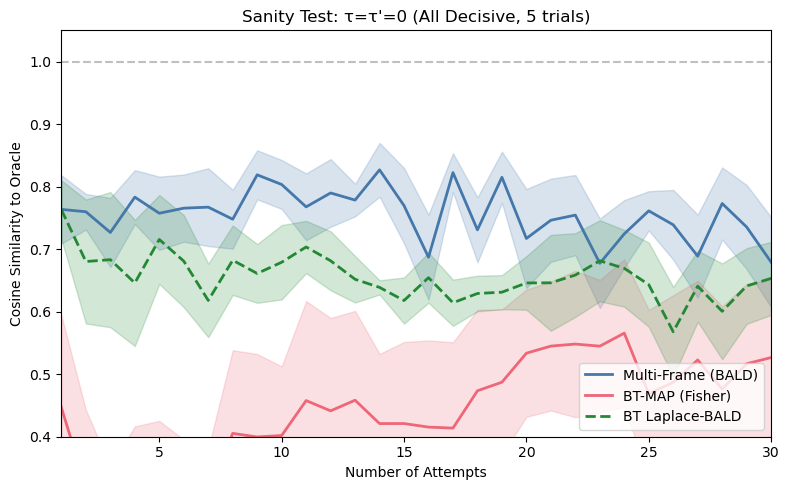


Interpretation:
  ✓ BT Laplace-BALD is closer to Multi-Frame than BT-MAP!
    Gap MF vs BT-MAP:     +0.153
    Gap MF vs BT-Laplace: +0.026
  → BALD acquisition helps close the gap between BT and MF


In [178]:
# ============================================================================
# CELL 36: Plot Sanity Test Results
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

attempts = np.arange(1, T_SANITY + 1)

# Multi-Frame
ax.plot(attempts, mf_mean, '-', color='#4477AA', linewidth=2, label='Multi-Frame (BALD)')
ax.fill_between(attempts, mf_mean - mf_se, mf_mean + mf_se, color='#4477AA', alpha=0.2)

# BT-MAP (Fisher)
ax.plot(attempts, bt_map_mean, '-', color='#EE6677', linewidth=2, label='BT-MAP (Fisher)')
ax.fill_between(attempts, bt_map_mean - bt_map_se, bt_map_mean + bt_map_se, color='#EE6677', alpha=0.2)

# BT Laplace-BALD
ax.plot(attempts, bt_laplace_mean, '--', color='#228833', linewidth=2, label='BT Laplace-BALD')
ax.fill_between(attempts, bt_laplace_mean - bt_laplace_se, bt_laplace_mean + bt_laplace_se, color='#228833', alpha=0.2)

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Number of Attempts')
ax.set_ylabel('Cosine Similarity to Oracle')
ax.set_title(f'Sanity Test: τ=τ\'=0 (All Decisive, {N_SANITY} trials)')
ax.legend(loc='lower right')
ax.set_ylim([0.4, 1.05])
ax.set_xlim([1, T_SANITY])

plt.tight_layout()
plt.savefig('sanity_test_laplace_bald.pdf', bbox_inches='tight', dpi=150)
plt.show()

print("\nInterpretation:")
gap_map = mf_mean[-1] - bt_map_mean[-1]
gap_laplace = mf_mean[-1] - bt_laplace_mean[-1]

if abs(gap_laplace) < abs(gap_map):
    print(f"  ✓ BT Laplace-BALD is closer to Multi-Frame than BT-MAP!")
    print(f"    Gap MF vs BT-MAP:     {gap_map:+.3f}")
    print(f"    Gap MF vs BT-Laplace: {gap_laplace:+.3f}")
    print(f"  → BALD acquisition helps close the gap between BT and MF")
else:
    print(f"  BT Laplace-BALD is NOT closer to Multi-Frame")
    print(f"    Gap MF vs BT-MAP:     {gap_map:+.3f}")
    print(f"    Gap MF vs BT-Laplace: {gap_laplace:+.3f}")

if abs(gap_laplace) < 0.02:
    print(f"\n  ✓ At τ=τ'=0, MF ≈ BT Laplace-BALD (gap < 0.02)")
    print(f"    This confirms both methods are equivalent when only decisive responses exist.")

# Grid Sweep: Multi-Frame vs BT Laplace-BALD

This experiment compares Multi-Frame (4-outcome BALD) vs BT Laplace-BALD (2-outcome BALD) across a grid of (τ, τ') values.

**Key settings:**
- `scale_delta = 1.0` for consistency (matches BT likelihood scale)
- BT uses Laplace posterior + BALD acquisition (apples-to-apples with MF)
- Each trial uses a different oracle sampled from Dirichlet(1,...,1)

**Expected results:**
- At τ=τ'=0: MF ≈ BT Laplace-BALD (both see only decisive responses)
- At large τ or τ': MF should outperform BT (MF uses indifferent/incomparable info)

In [179]:
# ============================================================================
# CELL 37: Grid Sweep - Multi-Frame vs BT Laplace-BALD
# ============================================================================
# Apples-to-apples comparison: both methods use BALD acquisition.
# scale_delta=1.0 for consistency (no likelihood scale mismatch).

# Grid parameters
TAUS_GRID = [0.0, 0.2, 0.4, 0.6, 0.8]
TAU_PRIMES_GRID = [0.0, 0.2, 0.4, 0.6, 0.8]

# Experiment parameters
T_GRID = 30           # Attempts per trial
N_GRID = 5           # Trials per cell (each with a different oracle)
SCALE_DELTA_GRID = 1.0  # Consistent scale
METHODS_GRID = ['multiframe', 'bt_laplace_bald']  # Both use BALD!

print(f"Grid Sweep: Multi-Frame vs BT Laplace-BALD")
print(f"=" * 50)
print(f"Grid: {len(TAUS_GRID)}×{len(TAU_PRIMES_GRID)} = {len(TAUS_GRID)*len(TAU_PRIMES_GRID)} cells")
print(f"Per cell: T={T_GRID} attempts × N={N_GRID} oracles × {len(METHODS_GRID)} methods")
print(f"scale_delta={SCALE_DELTA_GRID} (consistent)")
print(f"Methods: {METHODS_GRID}")
print()

# Run the sweep
grid_results_laplace = run_grid_sweep(
    taus=TAUS_GRID,
    tau_primes=TAU_PRIMES_GRID,
    dim=DIM,
    T=T_GRID,
    N=N_GRID,
    noise_type='logistic',
    scale_delta=SCALE_DELTA_GRID,
    scale_r=0.0,
    lambda_x=1.0,
    n_candidates=50,
    n_posterior_samples=200,
    methods=METHODS_GRID,
    seed=8000,
    verbose=True,
)

Grid Sweep: Multi-Frame vs BT Laplace-BALD
Grid: 5×5 = 25 cells
Per cell: T=30 attempts × N=5 oracles × 2 methods
scale_delta=1.0 (consistent)
Methods: ['multiframe', 'bt_laplace_bald']

Grid sweep: 5×5 = 25 cells
Methods: ['multiframe', 'bt_laplace_bald']
T=30 attempts, N=5 trials per cell (each trial = different oracle)
scale_delta=1.0, scale_r=0.0

  Cell 1/25: τ=0.0, τ'=0.0 → MF=0.820, BT-LB=0.782
  Cell 2/25: τ=0.0, τ'=0.2 → MF=0.766, BT-LB=0.746
  Cell 3/25: τ=0.0, τ'=0.4 → MF=0.757, BT-LB=0.725
  Cell 4/25: τ=0.0, τ'=0.6 → MF=0.757, BT-LB=0.822
  Cell 5/25: τ=0.0, τ'=0.8 → MF=0.834, BT-LB=0.790
  Cell 6/25: τ=0.2, τ'=0.0 → MF=0.988, BT-LB=0.763
  Cell 7/25: τ=0.2, τ'=0.2 → MF=0.980, BT-LB=0.830
  Cell 8/25: τ=0.2, τ'=0.4 → MF=0.991, BT-LB=0.875
  Cell 9/25: τ=0.2, τ'=0.6 → MF=0.987, BT-LB=0.836
  Cell 10/25: τ=0.2, τ'=0.8 → MF=0.904, BT-LB=0.837
  Cell 11/25: τ=0.4, τ'=0.0 → MF=0.988, BT-LB=0.873
  Cell 12/25: τ=0.4, τ'=0.2 → MF=0.998, BT-LB=0.831
  Cell 13/25: τ=0.4, τ'=0.4 → M

Saved to grid_sweep_mf_vs_bt_laplace_bald.pdf


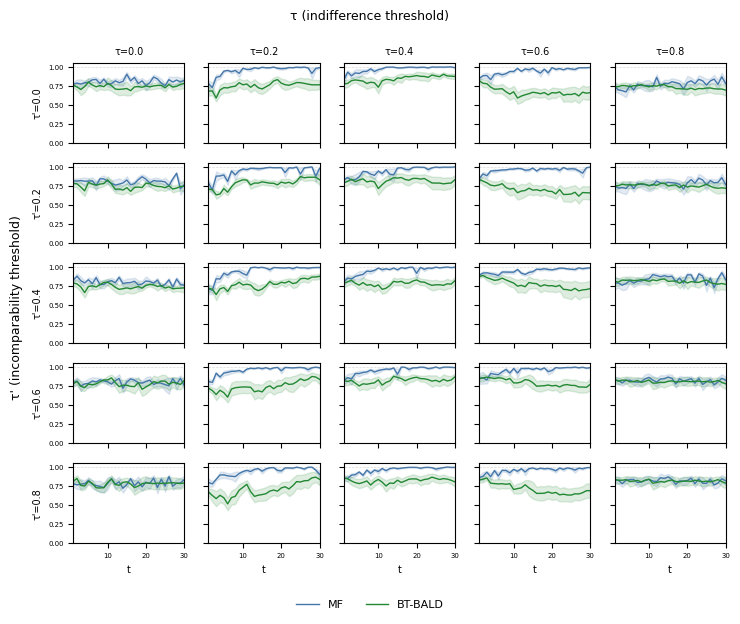

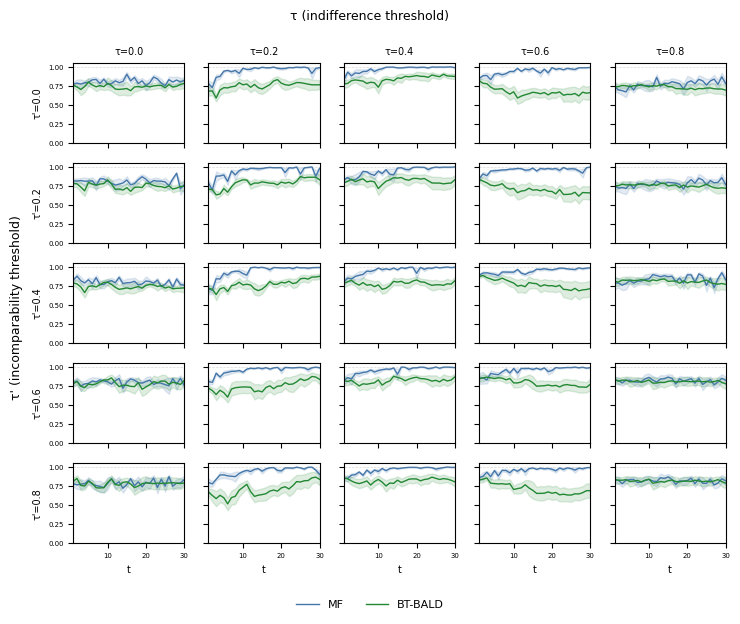

In [180]:
# ============================================================================
# CELL 38: Plot Grid Sweep Results - Convergence Curves
# ============================================================================

# Plot 9x9 grid of convergence curves
plot_grid_sweep(
    grid_results_laplace, 
    TAUS_GRID, 
    TAU_PRIMES_GRID, 
    T_GRID,
    methods_to_plot=['multiframe', 'bt_laplace_bald'],
    method_colors={'multiframe': '#4477AA', 'bt_laplace_bald': '#228833'},
    method_labels={'multiframe': 'MF', 'bt_laplace_bald': 'BT-BALD'},
    figsize_per_cell=(1.2, 1.0),
    show_stderr=True,
    save_path='grid_sweep_mf_vs_bt_laplace_bald.pdf'
)

Saved to heatmap_multiframe_laplace_exp.pdf


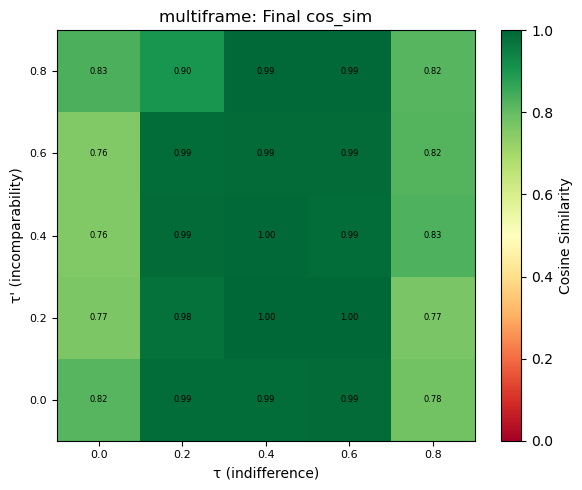

Saved to heatmap_bt_laplace_bald.pdf


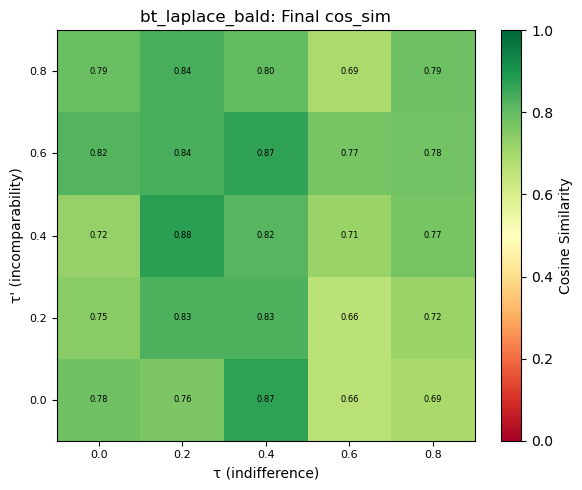

In [181]:
# ============================================================================
# CELL 39: Heatmaps - Final Cosine Similarity
# ============================================================================

# Heatmap for Multi-Frame
fig_mf, grid_mf = plot_grid_heatmap(
    grid_results_laplace, TAUS_GRID, TAU_PRIMES_GRID,
    method='multiframe',
    metric='final',
    save_path='heatmap_multiframe_laplace_exp.pdf'
)

# Heatmap for BT Laplace-BALD
fig_bt, grid_bt = plot_grid_heatmap(
    grid_results_laplace, TAUS_GRID, TAU_PRIMES_GRID,
    method='bt_laplace_bald',
    metric='final',
    save_path='heatmap_bt_laplace_bald.pdf'
)

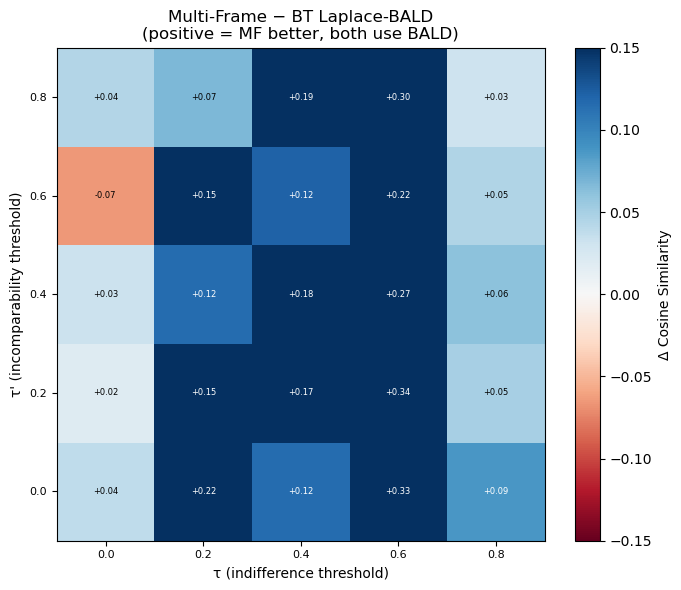

Saved difference heatmap to heatmap_diff_mf_bt_laplace_bald.pdf


In [182]:
# ============================================================================
# CELL 40: Difference Heatmap (MF - BT Laplace-BALD)
# ============================================================================

diff_grid = grid_mf - grid_bt

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(diff_grid, cmap='RdBu', vmin=-0.15, vmax=0.15, origin='lower', aspect='auto')

ax.set_xticks(range(len(TAUS_GRID)))
ax.set_xticklabels([f"{t:.1f}" for t in TAUS_GRID], fontsize=8)
ax.set_yticks(range(len(TAU_PRIMES_GRID)))
ax.set_yticklabels([f"{t:.1f}" for t in TAU_PRIMES_GRID], fontsize=8)

ax.set_xlabel('τ (indifference threshold)')
ax.set_ylabel("τ' (incomparability threshold)")
ax.set_title('Multi-Frame − BT Laplace-BALD\n(positive = MF better, both use BALD)')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Δ Cosine Similarity')

# Annotate
for i in range(len(TAU_PRIMES_GRID)):
    for j in range(len(TAUS_GRID)):
        val = diff_grid[i, j]
        if not np.isnan(val):
            color = 'white' if abs(val) > 0.08 else 'black'
            ax.text(j, i, f"{val:+.2f}", ha='center', va='center', fontsize=6, color=color)

plt.tight_layout()
plt.savefig('heatmap_diff_mf_bt_laplace_bald.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved difference heatmap to heatmap_diff_mf_bt_laplace_bald.pdf")

In [183]:
# ============================================================================
# CELL 41: Grid Sweep Summary
# ============================================================================

print("=" * 70)
print("GRID SWEEP SUMMARY: Multi-Frame vs BT Laplace-BALD")
print("=" * 70)
print(f"\nSettings: scale_delta={SCALE_DELTA_GRID}, T={T_GRID}, N={N_GRID} trials/cell")
print(f"Both methods use BALD acquisition for apples-to-apples comparison.\n")

print(f"Multi-Frame final cos_sim:")
print(f"  Mean across grid: {np.nanmean(grid_mf):.3f}")
print(f"  Min: {np.nanmin(grid_mf):.3f}")
print(f"  Max: {np.nanmax(grid_mf):.3f}")

print(f"\nBT Laplace-BALD final cos_sim:")
print(f"  Mean across grid: {np.nanmean(grid_bt):.3f}")
print(f"  Min: {np.nanmin(grid_bt):.3f}")
print(f"  Max: {np.nanmax(grid_bt):.3f}")

print(f"\nDifference (MF - BT Laplace-BALD):")
print(f"  Mean: {np.nanmean(diff_grid):+.3f}")
print(f"  Max advantage for MF: {np.nanmax(diff_grid):+.3f}")
print(f"  Max advantage for BT: {np.nanmin(diff_grid):+.3f}")

# Count cells where MF > BT
mf_wins = np.sum(diff_grid > 0.01)  # MF wins by >0.01
bt_wins = np.sum(diff_grid < -0.01)  # BT wins by >0.01
ties = len(TAUS_GRID) * len(TAU_PRIMES_GRID) - mf_wins - bt_wins

print(f"\nCell-wise comparison (threshold ±0.01):")
print(f"  MF better: {mf_wins}/{len(TAUS_GRID)*len(TAU_PRIMES_GRID)} cells")
print(f"  BT better: {bt_wins}/{len(TAUS_GRID)*len(TAU_PRIMES_GRID)} cells")
print(f"  Tied:      {ties}/{len(TAUS_GRID)*len(TAU_PRIMES_GRID)} cells")

# Check τ=τ'=0 specifically
if (0.0, 0.0) in grid_results_laplace:
    mf_00 = grid_results_laplace[(0.0, 0.0)]['multiframe']['mean'][-1]
    bt_00 = grid_results_laplace[(0.0, 0.0)]['bt_laplace_bald']['mean'][-1]
    print(f"\nAt τ=τ'=0 (all decisive):")
    print(f"  MF: {mf_00:.3f}, BT: {bt_00:.3f}, Gap: {mf_00 - bt_00:+.3f}")
    if abs(mf_00 - bt_00) < 0.02:
        print(f"  ✓ Methods are equivalent when only decisive responses exist!")

# Check where MF has biggest advantage
max_diff_idx = np.unravel_index(np.nanargmax(diff_grid), diff_grid.shape)
max_tau_prime = TAU_PRIMES_GRID[max_diff_idx[0]]
max_tau = TAUS_GRID[max_diff_idx[1]]
print(f"\nMF's biggest advantage at τ={max_tau}, τ'={max_tau_prime}: {np.nanmax(diff_grid):+.3f}")

print("\n" + "=" * 70)

GRID SWEEP SUMMARY: Multi-Frame vs BT Laplace-BALD

Settings: scale_delta=1.0, T=30, N=5 trials/cell
Both methods use BALD acquisition for apples-to-apples comparison.

Multi-Frame final cos_sim:
  Mean across grid: 0.909
  Min: 0.757
  Max: 0.998

BT Laplace-BALD final cos_sim:
  Mean across grid: 0.778
  Min: 0.657
  Max: 0.875

Difference (MF - BT Laplace-BALD):
  Mean: +0.131
  Max advantage for MF: +0.340
  Max advantage for BT: -0.065

Cell-wise comparison (threshold ±0.01):
  MF better: 24/25 cells
  BT better: 1/25 cells
  Tied:      0/25 cells

At τ=τ'=0 (all decisive):
  MF: 0.820, BT: 0.782, Gap: +0.038

MF's biggest advantage at τ=0.6, τ'=0.2: +0.340



RESPONSE DISTRIBUTION BY (τ, τ') - Multi-Frame Method

Percentage of each response type:

    τ    τ'  MF_left  MF_right  MF_indiff  MF_incompat  MF_decisive
  0.0   0.0     45.3      54.7        0.0          0.0        100.0
  0.0   0.2     46.0      48.0        0.0          6.0         94.0
  0.0   0.4     44.0      47.3        0.0          8.7         91.3
  0.0   0.6     43.3      42.0        0.0         14.7         85.3
  0.0   0.8     45.3      40.0        0.0         14.7         85.3
  0.2   0.0     30.7      34.0       35.3          0.0         64.7
  0.2   0.2     24.0      28.7       44.0          3.3         52.7
  0.2   0.4     26.0      26.7       44.0          3.3         52.7
  0.2   0.6     24.7      26.0       45.3          4.0         50.7
  0.2   0.8     22.7      27.3       45.3          4.7         50.0
  0.4   0.0     28.0      28.7       43.3          0.0         56.7
  0.4   0.2     24.7      24.7       48.7          2.0         49.3
  0.4   0.4     27.3      

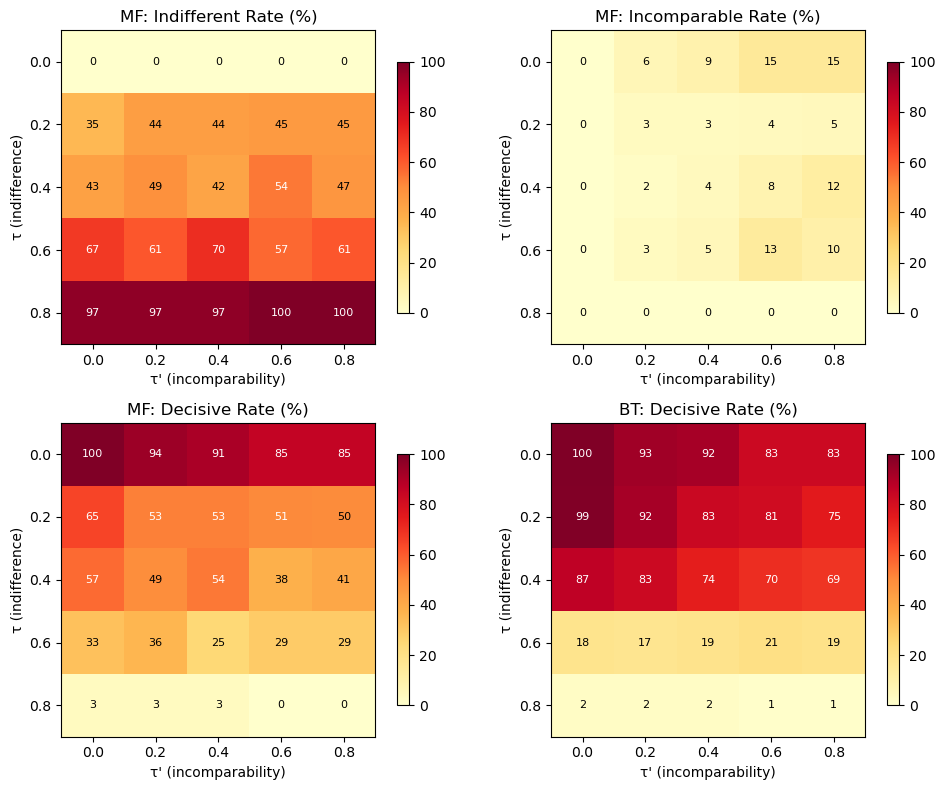


SUMMARY STATISTICS

At τ=τ'=0 (no indifference/incomparability):
  Decisive rate: 100.0%

At τ=τ'=0.4 (moderate thresholds):
  Indifferent: 42.0%
  Incomparable: 4.0%
  Decisive: 54.0%

At τ=τ'=0.8 (high thresholds):
  Indifferent: 100.0%
  Incomparable: 0.0%
  Decisive: 0.0%


In [184]:
# ============================================================================
# Response Distribution Analysis Across Grid
# ============================================================================
# Shows how response types (left, right, indifferent, incomparable) vary
# across different (τ, τ') combinations.

import pandas as pd

# Collect response distributions
response_data = []

for tau in TAUS_GRID:
    for tau_prime in TAU_PRIMES_GRID:
        cell_result = grid_results_laplace.get((tau, tau_prime), {})
        
        # Multi-frame responses
        mf_counts = cell_result.get('multiframe', {}).get('response_counts', {})
        mf_total = sum(mf_counts.values()) if mf_counts else 1
        
        # BT Laplace-BALD responses (from the oracle's perspective)
        bt_counts = cell_result.get('bt_laplace_bald', {}).get('response_counts', {})
        bt_total = sum(bt_counts.values()) if bt_counts else 1
        
        response_data.append({
            'τ': tau,
            "τ'": tau_prime,
            # Multi-frame percentages
            'MF_left': mf_counts.get('left', 0) / mf_total * 100,
            'MF_right': mf_counts.get('right', 0) / mf_total * 100,
            'MF_indiff': mf_counts.get('indifferent', 0) / mf_total * 100,
            'MF_incompat': mf_counts.get('incomparable', 0) / mf_total * 100,
            'MF_decisive': (mf_counts.get('left', 0) + mf_counts.get('right', 0)) / mf_total * 100,
            # BT responses (what oracle said, even though BT only uses decisive)
            'BT_left': bt_counts.get('left', 0) / bt_total * 100,
            'BT_right': bt_counts.get('right', 0) / bt_total * 100,
            'BT_indiff': bt_counts.get('indifferent', 0) / bt_total * 100,
            'BT_incompat': bt_counts.get('incomparable', 0) / bt_total * 100,
            'BT_decisive': (bt_counts.get('left', 0) + bt_counts.get('right', 0)) / bt_total * 100,
        })

df_responses = pd.DataFrame(response_data)

# Print summary table
print("=" * 80)
print("RESPONSE DISTRIBUTION BY (τ, τ') - Multi-Frame Method")
print("=" * 80)
print("\nPercentage of each response type:\n")
mf_cols = ['τ', "τ'", 'MF_left', 'MF_right', 'MF_indiff', 'MF_incompat', 'MF_decisive']
print(df_responses[mf_cols].to_string(index=False, float_format='%5.1f'))

print("\n" + "=" * 80)
print("RESPONSE DISTRIBUTION BY (τ, τ') - BT Laplace-BALD (Oracle Responses)")
print("=" * 80)
print("\nNote: BT only uses decisive (left/right) for inference, but oracle still gives all types.\n")
bt_cols = ['τ', "τ'", 'BT_left', 'BT_right', 'BT_indiff', 'BT_incompat', 'BT_decisive']
print(df_responses[bt_cols].to_string(index=False, float_format='%5.1f'))

# Visualize as heatmaps
print("\n" + "=" * 80)
print("HEATMAPS: Response Type Rates")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

response_types = [
    ('MF_indiff', 'MF: Indifferent Rate (%)', axes[0, 0]),
    ('MF_incompat', 'MF: Incomparable Rate (%)', axes[0, 1]),
    ('MF_decisive', 'MF: Decisive Rate (%)', axes[1, 0]),
    ('BT_decisive', 'BT: Decisive Rate (%)', axes[1, 1]),
]

for col, title, ax in response_types:
    # Reshape to grid
    grid = df_responses.pivot(index='τ', columns="τ'", values=col).values
    
    im = ax.imshow(grid, cmap='YlOrRd', aspect='equal', vmin=0, vmax=100)
    ax.set_xticks(range(len(TAU_PRIMES_GRID)))
    ax.set_xticklabels([f'{t:.1f}' for t in TAU_PRIMES_GRID])
    ax.set_yticks(range(len(TAUS_GRID)))
    ax.set_yticklabels([f'{t:.1f}' for t in TAUS_GRID])
    ax.set_xlabel("τ' (incomparability)")
    ax.set_ylabel('τ (indifference)')
    ax.set_title(title)
    
    # Add text annotations
    for i in range(len(TAUS_GRID)):
        for j in range(len(TAU_PRIMES_GRID)):
            val = grid[i, j]
            color = 'white' if val > 50 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', color=color, fontsize=8)
    
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('response_distribution_heatmaps.pdf', bbox_inches='tight')
plt.show()

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(f"\nAt τ=τ'=0 (no indifference/incomparability):")
row_00 = df_responses[(df_responses['τ'] == 0) & (df_responses["τ'"] == 0)].iloc[0]
print(f"  Decisive rate: {row_00['MF_decisive']:.1f}%")

print(f"\nAt τ=τ'=0.4 (moderate thresholds):")
row_04 = df_responses[(df_responses['τ'] == 0.4) & (df_responses["τ'"] == 0.4)].iloc[0]
print(f"  Indifferent: {row_04['MF_indiff']:.1f}%")
print(f"  Incomparable: {row_04['MF_incompat']:.1f}%")
print(f"  Decisive: {row_04['MF_decisive']:.1f}%")

print(f"\nAt τ=τ'=0.8 (high thresholds):")
row_08 = df_responses[(df_responses['τ'] == 0.8) & (df_responses["τ'"] == 0.8)].iloc[0]
print(f"  Indifferent: {row_08['MF_indiff']:.1f}%")
print(f"  Incomparable: {row_08['MF_incompat']:.1f}%")
print(f"  Decisive: {row_08['MF_decisive']:.1f}%")
